###### top
# Goal: Remove positional Bias that is causing uncertainty

# 1)[Try picking by region](#Try-picking-unbiased-by-region:-just-top-and-bottom-10)
# 2)[Plot Gene Diagrams with siRNA Target Site Positions](#Plot-Gene-Diagrams-with-siRNA-Target-Site-Positions)
# 3)[Try Sampling only one from each region](#Try-Selecting-only-one-from-each-region)
# 4)[Try Random Sampling/Statistical Boosting](#Try-Random-Sampling/Statistical-Boosting)



### [top](#top) | [bottom](#bottom)

# Try picking unbiased by region: just top and bottom 10
### [top](#top) | [bottom](#bottom)

In [67]:
df_bcam1 = df[(df['gene'] == 'BCAM1') & (df['old_screen_or_new'] == 'new')].copy()
df_gys1 = df[(df['gene'] == 'GYS1')& (df['old_screen_or_new'] == 'new')].copy()
df_mlh1 = df[(df['gene'] == 'MLH1')& (df['old_screen_or_new'] == 'new')].copy()
df_msh3 = df[(df['gene'] == 'MSH3')& (df['old_screen_or_new'] == 'new')].copy()

# df_bcam1 = df[(df['gene'] == 'BCAM1')].copy()
# df_gys1 = df[(df['gene'] == 'GYS1')].copy()
# df_mlh1 = df[(df['gene'] == 'MLH1')].copy()
# df_msh3 = df[(df['gene'] == 'MSH3')].copy()

df_bcam1.sort_values(by='raw_probabilities_mean',inplace=True,ascending=False)
df_gys1.sort_values(by='raw_probabilities_mean',inplace=True,ascending=False)
df_mlh1.sort_values(by='raw_probabilities_mean',inplace=True,ascending=False)
df_msh3.sort_values(by='raw_probabilities_mean',inplace=True,ascending=False)

df_bcam1.reset_index(inplace=True,drop=True)
df_gys1.reset_index(inplace=True,drop=True)
df_mlh1.reset_index(inplace=True,drop=True)
df_msh3.reset_index(inplace=True,drop=True)

bcam1_top_indx = list(df_bcam1[0:10].index)
bcam1_bottom_indx = list(df_bcam1[-10:].index)

gys1_top_indx = list(df_gys1[0:10].index)
gys1_bottom_indx = list(df_gys1[-10:].index)

mlh1_top_indx = list(df_mlh1[0:10].index)
mlh1_bottom_indx = list(df_mlh1[-10:].index)

msh3_top_indx = list(df_msh3[0:10].index)
msh3_bottom_indx = list(df_msh3[-10:].index)


Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	TRYING-TO-UNBIAS-POSITION_picking_top_10_bottom_10_by_score.png
	TRYING-TO-UNBIAS-POSITION_picking_top_10_bottom_10_by_score.svg


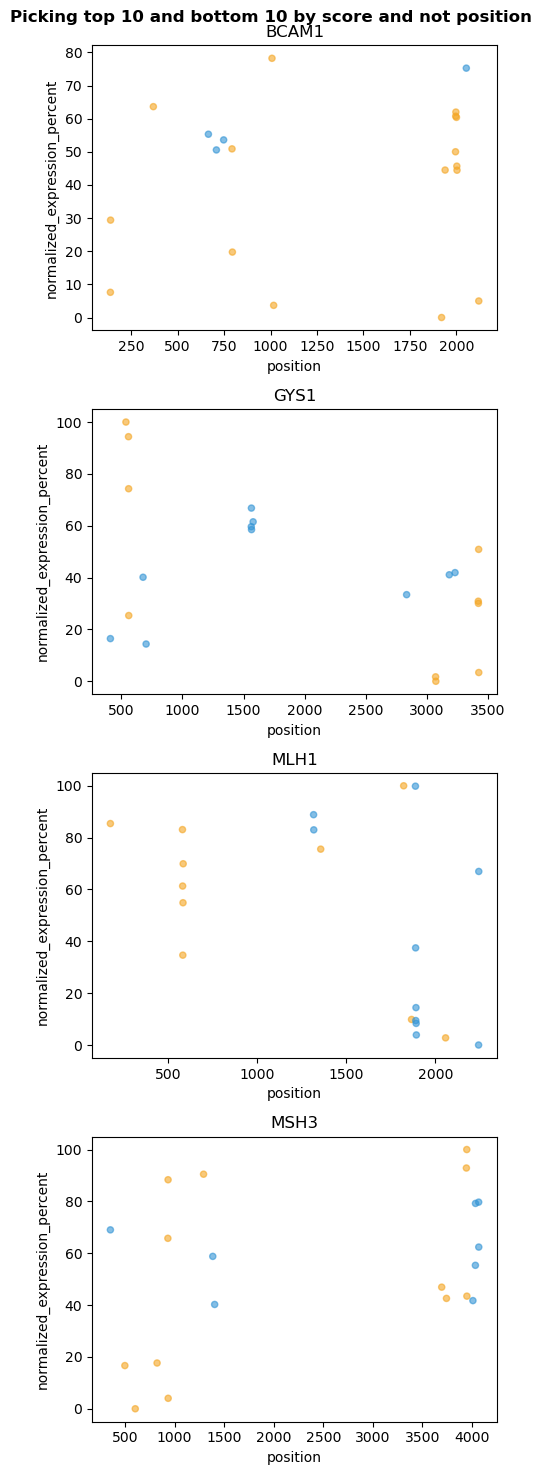

In [72]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
# sklearn.metrics.confusion_matrix(y_true,y_pred)#,*,labels=None,sample_weight=None,normalize=None)


import matplotlib.pyplot as plt
import matplotlib.colors
import numpy as np





# df_bcam1.iloc[bcam1_top_indx+bcam1_bottom_indx]
# df_gys1.iloc[gys1_top_indx+gys1_bottom_indx]
# df_mlh1.iloc[mlh1_top_indx+mlh1_bottom_indx]
# df_msh3.iloc[msh3_top_indx+msh3_bottom_indx]

fig,axs = plt.subplots(4)
fig.set_size_inches(w=5,h=15)

df_bcam1.iloc[bcam1_top_indx+bcam1_bottom_indx].plot.scatter(
        
        x='position',
        
        # y='avg_raw_expression_percent',
        y='normalized_expression_percent',
        marker='o',
        alpha=0.6,
        c = list(df_bcam1.iloc[bcam1_top_indx+bcam1_bottom_indx]['predicted_functional'].apply(lambda x: class_color_dict[int(x >= 0.5)])),
    
        ax=axs[0],
        title='BCAM1',
)


df_gys1.iloc[gys1_top_indx+gys1_bottom_indx].plot.scatter(
        
        x='position',
    
        # y='avg_raw_expression_percent',
        y='normalized_expression_percent',
        marker='o',
        alpha=0.6,
        c = list(df_gys1.iloc[gys1_top_indx+gys1_bottom_indx]['predicted_functional'].apply(lambda x: class_color_dict[int(x >= 0.5)])),
    
        ax=axs[1],
        title='GYS1',

)

df_mlh1.iloc[mlh1_top_indx+mlh1_bottom_indx].plot.scatter(
        
        x='position',
    
        # y='avg_raw_expression_percent',
        y='normalized_expression_percent',
        marker='o',
        alpha=0.6,
        c = list(df_mlh1.iloc[mlh1_top_indx+mlh1_bottom_indx]['predicted_functional'].apply(lambda x: class_color_dict[int(x >= 0.5)])),
    
        ax=axs[2],
        title='MLH1',
)


df_msh3.iloc[msh3_top_indx+msh3_bottom_indx].plot.scatter(
        
        x='position',
    
        # y='avg_raw_expression_percent',
        y='normalized_expression_percent',
        marker='o',
        alpha=0.6,
        c = list(df_msh3.iloc[msh3_top_indx+msh3_bottom_indx]['predicted_functional'].apply(lambda x: class_color_dict[int(x >= 0.5)])),
    
        ax=axs[3],
        title='MSH3',
)
fig.suptitle('Picking top 10 and bottom 10 by score and not position',fontweight='bold')
fig.tight_layout()

fig.tight_layout()


## Save Figure
fnm_final_ = 'TRYING-TO-UNBIAS-POSITION_picking_top_10_bottom_10_by_score'

fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
fig.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
fig.savefig(fnm_final_dir_+fnm_final_+'.svg',format='svg',transparent=True)
fig.savefig(fnm_final_dir_+fnm_final_+'.png',format='png',dpi=300,transparent=False)
print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final_ + '.png\n\t'+ fnm_final_ + '.svg')



## CONCLUSION FROM (1)
## *See that when select without positional bias and instead just by top and bottom score, the siRNAs are still biased by position, so it is inherent to the siRNAs selected* 
### Need to try something else

In [138]:
import pandas as pd
import numpy as np

df= pd.read_csv('combined_experimental_validation_ssrf.csv')

df

df_old = df[df['old_screen_or_new'] == 'old'].copy()
df_old

df = df[df['old_screen_or_new'] == 'new'].copy()
df


,oligo,gene,predicted_functional,actually_functional,raw_prob_preds_1,raw_prob_preds_2,raw_prob_preds_3,raw_prob_preds_4,raw_prob_preds_5,raw_prob_preds_6,...,prob_preds_norm_by_round_3,prob_preds_norm_by_round_4,prob_preds_norm_by_round_5,prob_preds_norm_by_round_6,prob_preds_norm_by_round_7,prob_preds_norm_by_round_8,prob_preds_norm_by_round_9,prob_preds_norm_by_round_10,mean_prob_preds_norm_by_round,TESTING_threshold_score
0,BCAM1_1920,BCAM1,True,True,0.533778,0.501677,0.532887,0.510768,0.510622,0.530200,...,79.3,62.9,63.0,74.4,92.0,82.3,67.6,82.7,73.84,0.000000
1,MLH1_2242,MLH1,False,True,0.431430,0.415871,0.444473,0.449530,0.464387,0.454922,...,27.8,29.8,31.7,30.8,29.1,13.9,21.5,17.0,21.58,0.000000
2,GYS1_3072,GYS1,True,True,0.538398,0.506327,0.528530,0.529311,0.553833,0.501433,...,76.7,72.9,92.3,57.8,77.7,91.9,70.2,76.9,75.65,0.000000
4,MSH3_603,MSH3,True,True,0.535627,0.527358,0.493594,0.508455,0.502248,0.544871,...,56.4,61.6,57.3,82.9,59.8,69.0,66.7,54.6,65.97,0.000000
9,GYS1_3070,GYS1,True,True,0.512966,0.537815,0.534843,0.528372,0.544405,0.531601,...,80.4,72.4,85.9,75.2,85.0,65.6,80.7,86.6,77.50,0.015463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,MLH1_1888,MLH1,False,False,0.425828,0.430559,0.455038,0.431385,0.447930,0.436413,...,34.0,20.0,20.5,20.1,11.6,27.4,5.1,21.5,18.00,3.883177
191,MSH3_3948,MSH3,True,False,0.537318,0.552231,0.548806,0.514997,0.522056,0.501626,...,88.5,65.2,70.8,57.9,72.3,78.2,81.1,86.4,76.84,0.910984
192,GYS1_538,GYS1,True,False,0.532229,0.524898,0.517820,0.557338,0.514710,0.524205,...,70.5,88.0,65.8,70.9,94.1,88.8,78.5,63.7,76.80,0.911458
193,BCAM1_1546,BCAM1,False,False,0.418919,0.439839,0.431904,0.432702,0.418415,0.451912,...,20.5,20.8,0.5,29.1,43.2,24.1,11.1,21.9,19.23,3.640146


In [139]:
class_color_dict = {1:'#F4A624',0:'#3294D5'}

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
# sklearn.metrics.confusion_matrix(y_true,y_pred)#,*,labels=None,sample_weight=None,normalize=None)


import matplotlib.pyplot as plt
import matplotlib.colors
import numpy as np

def colormap_to_hex_list(cmap_name,num_colors):
    """
    Generates a list of hex colors from a Matplotlib colormap.

    Args:
        cmap_name (str): Name of the Matplotlib colormap.
        num_colors (int): Number of colors to sample from the colormap.

    Returns:
        list: A list of hex color strings.
    """
    cmap = plt.cm.get_cmap(cmap_name,num_colors)
    colors = cmap(np.linspace(0,1,num_colors))
    hex_colors = [matplotlib.colors.to_hex(color) for color in colors]
    return hex_colors

# Example usage:
cmap_name = 'gist_rainbow'
num_colors = 100
hex_color_list = colormap_to_hex_list(cmap_name,num_colors)


    

BCAM1
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	BCAM1_plot_positoin_vs_expr-pcnt_old_vs_new.png
	BCAM1_plot_positoin_vs_expr-pcnt_old_vs_new.svg
GYS1
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	GYS1_plot_positoin_vs_expr-pcnt_old_vs_new.png
	GYS1_plot_positoin_vs_expr-pcnt_old_vs_new.svg
MLH1
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	MLH1_plot_positoin_vs_expr-pcnt_old_vs_new.png
	MLH1_plot_positoin_vs_expr-pcnt_old_vs_new.svg
MSH3
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	MSH3_plot_positoin_vs_expr-pcnt_old_vs_new.png
	MSH3_plot_positoin_vs_expr-pcnt_old_vs_new.svg


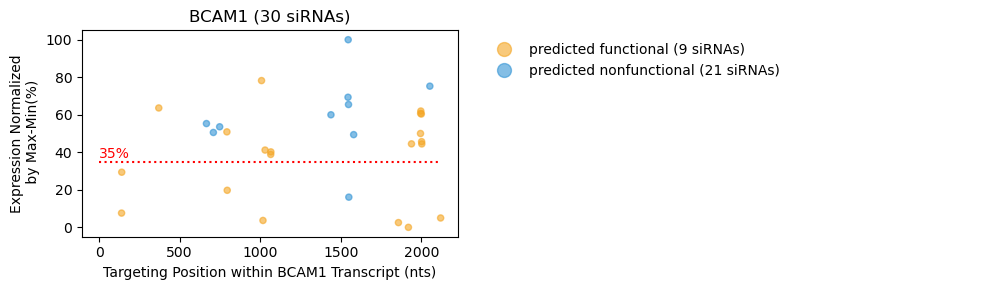

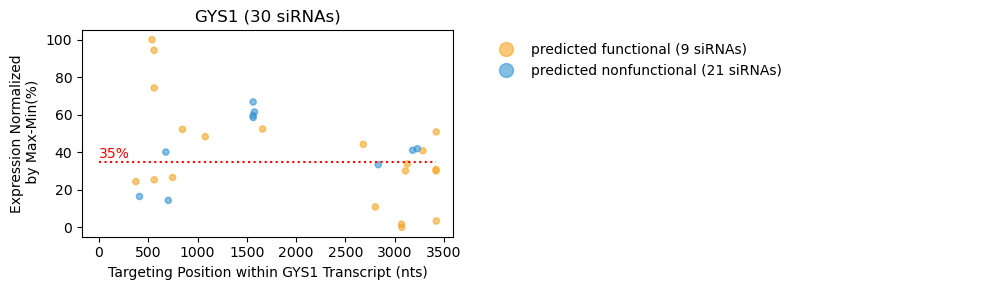

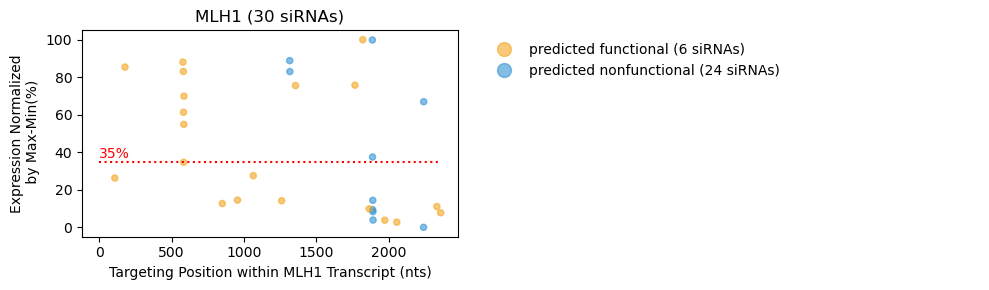

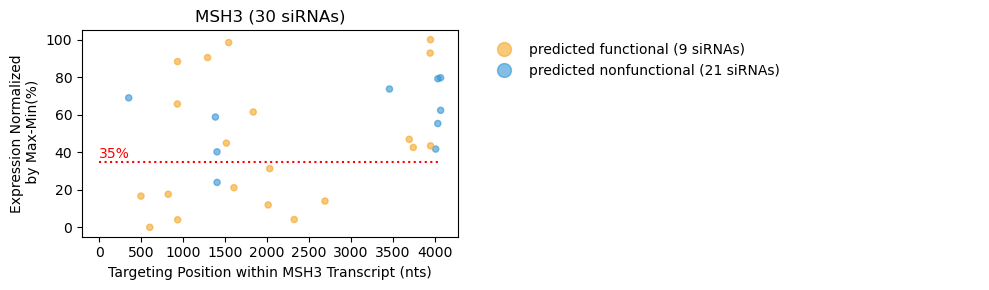

In [140]:


for gene_ in ['BCAM1','GYS1','MLH1','MSH3']: # list(df['gene'].value_counts().index)
    fig,axs = plt.subplots(1,2)
    fig.set_size_inches(w=10,h=3)
    print(gene_)

    # colors_ls_new_screen_by_score = df[(df['gene'] == gene_) & 
    # (df['old_screen_or_new'] == 'new') ]['aver'].apply(lambda x: hex_color_list[int(np.round(x*100,2))])
    colors_ls_new_screen_by_score = df[(df['gene'] == gene_) & 
    (df['old_screen_or_new'] == 'new') ]['aver'].apply(lambda x: class_color_dict[int(x >= 0.5)])


    
    df[(df['gene'] == gene_) & (df['old_screen_or_new'] == 'new')].plot.scatter(
        
        #x='raw_probabilities_mean',
        # x='score_avg_probabilities',
        # x = 'score_max_probabilities',
        x='position',
    
        # y='avg_raw_expression_percent',
        y='normalized_expression_percent',
        marker='o',
        alpha=0.6,
        c=colors_ls_new_screen_by_score,
    
        ax=axs[0],
    )

    
    # colors_ls_old_screen_by_score = df[(df['gene'] == gene_) & 
    # (df['old_screen_or_new'] == 'old') ]['aver'].apply(lambda x: hex_color_list[int(np.round(x*100,2))])
    colors_ls_old_screen_by_score = df[(df['gene'] == gene_) & 
    (df['old_screen_or_new'] == 'old') ]['aver'].apply(lambda x: class_color_dict[int(x >= 0.5)])



    
    # Legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    legend_elements=[
        # Line2D([0],[0],marker='o',color='black',linestyle='None',markersize=10,label='new screen ('+str(len(df[(df['gene'] == gene_) & (df['old_screen_or_new'] == 'new') ]))+' siRNAs)',alpha=0.6),
        # Line2D([0],[0],marker='x',color='black',linestyle='None',markersize=10,label='old screen ('+str(len(df[(df['gene'] == gene_) & (df['old_screen_or_new'] == 'old') ]))+' siRNAs)',alpha=0.6),
        Line2D([0],[0],marker='o',color=class_color_dict[1],linestyle='None',markersize=10,label='predicted functional ('+str(len(df[(df['gene'] == gene_) & (df['old_screen_or_new'] == 'new') & (df['min_pred_score'] >= 0.5) ]))+' siRNAs)',alpha=0.6),
        Line2D([0],[0],marker='o',color=class_color_dict[0],linestyle='None',markersize=10,label='predicted nonfunctional ('+str(len(df[(df['gene'] == gene_) & (df['old_screen_or_new'] == 'new') & (df['min_pred_score'] < 0.5) ]))+' siRNAs)',alpha=0.6),
        # Line2D([0],[0],marker='o',color=gene_color_dict[gene_],linestyle='None',markersize=10,label='new screen ('+str(len(df[(df['gene'] == gene_) & (df['old_screen_or_new'] == 'new') ]))+' siRNAs)',alpha=0.6),
        # Line2D([0],[0],marker='x',color=gene_color_dict[gene_],linestyle='None',markersize=10,label='old screen ('+str(len(df[(df['gene'] == gene_) & (df['old_screen_or_new'] == 'old') ]))+' siRNAs)',alpha=0.6),
    ]
    axs[1].legend(handles=legend_elements,loc='upper right',frameon=False,fontsize=10,bbox_to_anchor=(0.5, 1.0))
    

    
    axs[0].set_title(gene_+' ('+str(len(df[df['gene'] == gene_]))+' siRNAs)')

    
    axs[0].set_xlabel('Targeting Position within '+gene_+' Transcript (nts)')
    axs[0].set_ylabel('Expression Normalized\n by Max-Min(%)')
    
    # prob_co_ = 0.5
    # axs[0].annotate(str(prob_co_),(prob_co_,0),color='blue')
    # axs[0].vlines(x=prob_co_,ymin=0,ymax=100,linestyle='dotted',color='blue')
    
    expr_co_ = 35
    axs[0].hlines(y=expr_co_, xmin=0, xmax=(max(df[(df['gene'] == gene_)]['position'])), linestyle='dotted',color='red')
    axs[0].annotate(str(expr_co_)+'%',(0.40,expr_co_+2),color='red')

    # cm = confusion_matrix(df[df['gene'] == gene_]['actually_functional'],
    #              df[df['gene'] == gene_]['predicted_functional'] )

    # disp = ConfusionMatrixDisplay(confusion_matrix=cm,
    #                               display_labels=["Nonfunctional","Functional"])
    # disp.plot(ax=axs[1])
    # axs[1].set_title(gene_+' ('+str(len(df[df['gene'] == gene_]))+' siRNAs)')

    
    #axs[1].remove()
    # axs[1].get_yaxis().set_visible(False)
    # axs[1].get_xaxis().set_visible(False)
    axs[1].axis('off')


    ## Save Figure
    fnm_final_ = gene_.upper()+'_plot_positoin_vs_expr-pcnt_old_vs_new'
    
    fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
    fig.tight_layout()
    plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
    fig.savefig(fnm_final_dir_+fnm_final_+'.svg',format='svg',transparent=True)
    fig.savefig(fnm_final_dir_+fnm_final_+'.png',format='png',dpi=300,transparent=False)
    print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final_ + '.png\n\t'+ fnm_final_ + '.svg')



# Plot Gene Diagrams with siRNA Target Site Positions

#### [top](#top) | [bottom](#bottom)

15
17
16
19
Figures saved to:
  
	plot_all_positions_4_genes.png
	plot_all_positions_4_genes.svg


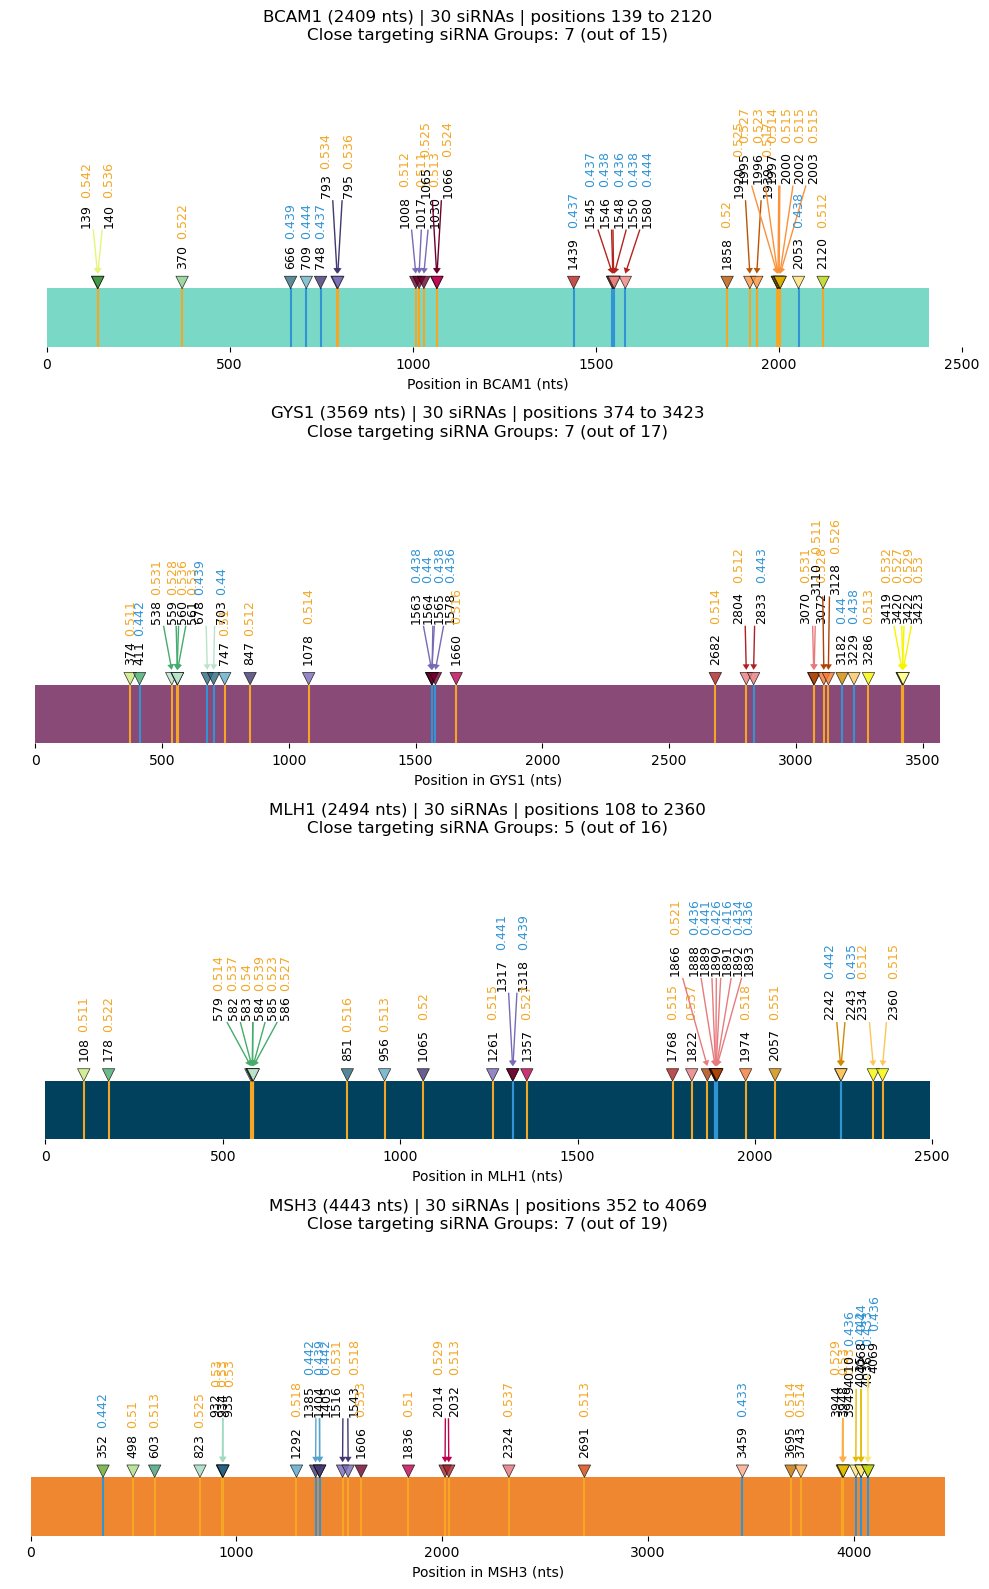

In [1198]:
from matplotlib.patches import Rectangle 

# Darken Hex Colors
# Need to have installed:
# pip install colormap
# pip install easydev

    
def darken_color(hex_number, factor=0.1):
    import seaborn as sns
    import numpy as np
    from colormap import rgb2hex, rgb2hls, hls2rgb

    
    hex = hex_number[1:]#.lstrip('#')
    hlen = len(hex)
    r,g,b = tuple(int(hex[i:i+hlen//3], 16) for i in range(0, hlen, hlen//3))


    h, l, s = rgb2hls(r / 255.0, g / 255.0, b / 255.0)
    l = max(min(l * factor, 1.0), 0.0)
    r, g, b = hls2rgb(h, l, s)
    return rgb2hex(int(r * 255), int(g * 255), int(b * 255))
    



# Start with hex value --> darker hex_value
# hex_number = '#ee48e7'
# hex_number_dark = darken_color(hex_number, factor=0.5)
# import seaborn as sns
# sns.palplot([hex_number])
# sns.palplot([hex_number_dark])


df_gene_dict = {
    'BCAM1':df_bcam1,
    'MSH3': df_msh3,
    'GYS1': df_gys1,
    'MLH1': df_mlh1,#XM_005265161
}

gene_len_dict = {
    'BCAM1':2409,# NM_005581
    'MSH3': 4443, #NM_002439
    'GYS1': 3569,#NM_001161587 --> 3377nts, NM_002103 --> 3569 nts
    'MLH1': 2494,#XM_005265161 --> 2287nts , NM_000249.4 --> 2494 nts
}

gene_color_dict


fig,axs = plt.subplots(4)
fig.set_size_inches(w=10,h=16)
ct_ = 0
for gene_ in ['BCAM1','GYS1','MLH1','MSH3']: # list(df['gene'].value_counts().index)
    df_gene_=df_gene_dict[gene_].copy()
    df_gene_.sort_values(by='position',inplace=True)
    df_gene_.reset_index(inplace=True,drop=True)
    # display(df_gene_['position'])
    ax_i_ = axs[ct_]

    
    colors_by_predicted_class = df_gene_['aver'].apply(lambda x: class_color_dict[int(x >= 0.5)])


    max_targ_pos_ = max(df_gene_['position'])
    min_targ_pos_ = min(df_gene_['position'])

    gene_length = gene_len_dict[gene_]
    
    
    
    all_nts_gene_ = list(np.arange(0,gene_length))

    targ_pos_actual_gene_ = list(df_gene_['position'])

     # is_targ_pos_gene_ list where 1 if targeting at position, 0 if not
    is_targ_pos_gene_ = [0]*len(all_nts_gene_)
    for i in targ_pos_actual_gene_:
        is_targ_pos_gene_[i] = 1

    # display(('Positions in '+gene_+' Targeted:'),pd.Series(is_targ_pos_gene_).apply(lambda x: bool(x)).value_counts())

    all_targ_pos_gene_ = len(targ_pos_actual_gene_)*[1]






    # Identify positions that are close together
    distance_close_targeting_ = 30
    pos_prev_ = 0
    gene_pos_groups_=[]
    df_gene_['position_targeting_group'] = np.nan
    pos_targ_group_num = 1
    for index, row in df_gene_.iterrows():
        pos_ = row['position']
        if pos_prev_ ==0:
            gene_pos_groups_+=[[pos_]]
            
        elif  pos_-distance_close_targeting_ <= pos_prev_:
            # print(pos_prev_,pos_)
            gene_pos_groups_[-1].append(pos_)
            
        else:
            gene_pos_groups_+=[[pos_]]
            pos_targ_group_num+=1
            
        df_gene_.at[index,'position_targeting_group'] = str(pos_targ_group_num)
        pos_prev_ = pos_
    
    info_group_txt_ = ('Close targeting siRNA Groups: '+str(len([x for x in gene_pos_groups_ if len(x) > 1]))+' (out of '+str(len(gene_pos_groups_))+')')
    # print(info_group_txt_)
    # [print(x) for x in gene_pos_groups_ if len(x) > 1]

    num_position_targ_groups_gene_ = len(df_gene_['position_targeting_group'].value_counts().index)



    
    
    # Draw rectangle for gene bar
    rect = Rectangle((0, 0), gene_length, 1, linewidth=0, edgecolor='none', facecolor=gene_color_dict[gene_])
    ax_i_.add_patch(rect)

    # ax_i_.bar(
        
    #     x=all_nts_gene_,
    #     height=targ_pos_gene_,
    #     # alpha=0.6,
    #     # c='color',
    # )

    # ## Add labels for target positions colored by predicted efficacy class
    # carrot_locs = ax_i_.scatter(
    #     x=targ_pos_actual_gene_,
    #     y=len(targ_pos_actual_gene_)*[0.5],
    #     alpha=0.6,
    #     c=colors_by_predicted_class,
    #     marker='|',
    #     s=50,
        
    # )

    # Add Vertical lines for each point targeted colored by efficacy
    for i,p_ in enumerate(targ_pos_actual_gene_):
        ax_i_.vlines(p_, 0, 1, colors=colors_by_predicted_class[i], linestyles='solid',  label='')

    
    
    
    ## Add second set of labels colored by position group
    cmap_name = 'Spectral'#'rainbow'#'gist_rainbow'
    num_colors = num_position_targ_groups_gene_ +2
    #colors_for_groups = colormap_to_hex_list(cmap_name,num_colors)



    colors_for_groups = colormap_to_hex_list(cmap_name,int(num_colors/2))
    paired_col_ls_ =[]
    col_ct_=0
    for c_ in colors_for_groups:
        if col_ct_ >int(len(colors_for_groups)/2)-3 and col_ct_ < int(len(colors_for_groups)/2)+2:
            paired_col_ls_.append(darken_color(c_, factor=0.55))   
            paired_col_ls_.append(darken_color(c_, factor=0.9))   
            # paired_col_ls_.append(c_)
            # sns.palplot([c_])
        else:
            paired_col_ls_.append(darken_color(c_, factor=0.7))   
            # paired_col_ls_.append(c_)
            paired_col_ls_.append(darken_color(c_, factor=1.2))
        col_ct_+=1


        
    # sns.palplot(paired_col_ls_)


    colors_for_groups = paired_col_ls_
    
    # sns.palplot(colors_for_groups)
    # Reorder colors so yellow isn't in middle
    start_col_index = int(np.round(len(colors_for_groups)/2))+1
    reordered_colors_for_groups = colors_for_groups[start_col_index:]+colors_for_groups[0:start_col_index]
    # reordered_colors_for_groups = colors_for_groups
    # sns.palplot(reordered_colors_for_groups)
    colors_by_targ_pos_group_ = df_gene_['position_targeting_group'].apply(lambda x: reordered_colors_for_groups[int(x)])
    # sns.palplot(colors_by_targ_pos_group_)

    carrot_locs_col_by_group = ax_i_.scatter(
        x=targ_pos_actual_gene_,
        y=len(targ_pos_actual_gene_)*[1.1],
        alpha=0.8,
        c=colors_by_targ_pos_group_,
        edgecolor='black',
        linewidth=0.5,
        #edgecolors=colors_by_predicted_class,
        marker='v',
        s=80,
        zorder=1000,
        
    )



    # Add labels above each point containing scores
    #   But treat positions close to each other differently

    print(num_position_targ_groups_gene_)
    group_annote_ct_ = 0
    prev_pos_targ_group_ = 0
    prev_x_pos_max_group_ = 0



    # y_pos_arrow_text_nudge = 0
    nudge_spacing_ =100
    nudge_amt_y_ = 0.5
    max_pos_grp_dict= {}
    for grp in df_gene_['position_targeting_group'].value_counts().index:
        max_pos_grp_dict[grp]=max(df_gene_[df_gene_['position_targeting_group'] == str(grp)]['position'])
    nudge_y_pos_group_dict={}
    prev_pos__ = 0
    for indx in range(num_position_targ_groups_gene_):
        max_pos_ = (max_pos_grp_dict[str(indx+1)])
        if max_pos_-prev_pos__ <nudge_spacing_:
            if (nudge_y_pos_group_dict[str(indx)] == nudge_amt_y_) :
                nudge_y_pos_group_dict[str(indx+1)] = nudge_y_pos_group_dict[str(indx)]+0.5*nudge_amt_y_
            else:
                nudge_y_pos_group_dict[str(indx+1)] = nudge_amt_y_
        else:
            nudge_y_pos_group_dict[str(indx+1)] = 0
        prev_pos__ = max_pos_
    


    
    for indx, pos in enumerate(list(df_gene_['position'])):
        score_y_nudge = 0
        if pos > 1000:
            score_y_nudge = 0.2
        score_ = np.round(df_gene_.at[indx,'aver'],3)
        targ_group__ = df_gene_.at[indx,'position_targeting_group']
        size_targ_group_ = df_gene_['position_targeting_group'].value_counts()[str(targ_group__)]
        x_pos_ = df_gene_.at[indx,'position']
        y_pos_ = 1.4
        if size_targ_group_ == 1:
            ax_i_.annotate(pos, (x_pos_, y_pos_),
                           fontsize=9,ha='center',va='baseline',rotation=90)
            ax_i_.annotate(score_, (x_pos_, y_pos_+0.5+score_y_nudge),
                        fontsize=9,ha='center',va='baseline',rotation=90,color=colors_by_predicted_class[indx])
        else:
            # plot arrows with annotation one for each in size_targ_group_
            y_pos_arrow_text_=2.1
            # move labels up if close to previous group arrows
            y_pos_arrow_text_nudge=nudge_y_pos_group_dict[targ_group__]
            # x_pos_arrow_text_ = x_pos_-50
            y_pos_arrow_tip_ = 1.25
            x_pos_max_group_ = max(df_gene_[df_gene_['position_targeting_group'] == targ_group__]['position'])

            
                
                
            # Check if this is a new group or if already plotted some arrows
            if indx !=0 and targ_group__ == prev_pos_targ_group_:
                group_annote_ct_+=1

                
            else:
                group_annote_ct_ = 0 # restart the counter
                prev_x_pos_max_group_ = x_pos_max_group_
                
            spacing__ = 30
            start_arrow_ann_ = x_pos_-(int(size_targ_group_/2)*spacing__)
            end_arrow_ann_ = x_pos_max_group_+(int(size_targ_group_/2)*spacing__)
            arrow_ann_x_pos_ls_=np.linspace(start_arrow_ann_, end_arrow_ann_, size_targ_group_)
            x_pos_arrow_text_ = arrow_ann_x_pos_ls_[group_annote_ct_]
            
            ax_i_.annotate(pos, xy=(x_pos_, y_pos_arrow_tip_), xytext=(x_pos_arrow_text_, y_pos_arrow_text_+y_pos_arrow_text_nudge),
                        fontsize=9,ha='center',va='baseline',rotation=90,color='black',
                        arrowprops=dict(facecolor=reordered_colors_for_groups[int(targ_group__)-1], linewidth=0,width=1,headlength=4,headwidth=5))#,frac=2))#, shrink=0.001))
            
            ax_i_.annotate(score_, (x_pos_arrow_text_, y_pos_arrow_text_+y_pos_arrow_text_nudge+0.5+score_y_nudge),
                        fontsize=9,ha='center',va='baseline',rotation=90,color=colors_by_predicted_class[indx])
            

        prev_pos_targ_group_ = targ_group__



    
    
    ax_i_.set_yticks([])
    ax_i_.set_xlabel('Position in '+gene_+' (nts)')
    title_ = (gene_+' ('+str(gene_length)+' nts) | '+str(len(targ_pos_actual_gene_))+
              ' siRNAs | positions '+str(min_targ_pos_)+' to '+str(max_targ_pos_)+'\n'+info_group_txt_)
    ax_i_.set_title(title_)
    ax_i_.set_xlim(0,max_gene_pos+50)
    

    
    ax_i_.set_ylim(0,5.1)
    ax_i_.set_xlim(-100,gene_length+100)

    ax_i_.set_frame_on(False)
    

    
    ct_+=1
    
fig.tight_layout()


# ## Save Figure
fnm_final_ = 'plot_all_positions_4_genes'

fnm_final_dir_ = ''#'/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
fig.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
fig.savefig(fnm_final_dir_+fnm_final_+'.svg',format='svg',transparent=True)
fig.savefig(fnm_final_dir_+fnm_final_+'.png',format='png',dpi=300,transparent=False)
print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final_ + '.png\n\t'+ fnm_final_ + '.svg')



## Conclusion from Plotting:
#### There are a lot of regions that are biased based on selection where we initially picked a high scoring siRNA in that region but then selected several nearby
#### We could resample without bias (picking only the top scores) and thus remove the biased additions and only keep the initially selected top scoring siRNAs

# Try Selecting only one from each region
## Removing biased siRNAs that were selected manually without considering score but only position
### [top](#top) | [bottom](#bottom)

Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	BCAM1_TRYING-TO-UNBIAS-POSITION_picking_top_10_bottom_10_by_score.png
	BCAM1_TRYING-TO-UNBIAS-POSITION_picking_top_10_bottom_10_by_score.svg
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	MSH3_TRYING-TO-UNBIAS-POSITION_picking_top_10_bottom_10_by_score.png
	MSH3_TRYING-TO-UNBIAS-POSITION_picking_top_10_bottom_10_by_score.svg
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	MLH1_TRYING-TO-UNBIAS-POSITION_picking_top_10_bottom_10_by_score.png
	MLH1_TRYING-TO-UNBIAS-POSITION_picking_top_10_bottom_10_by_score.svg
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	GYS1_TRYING-TO-UN

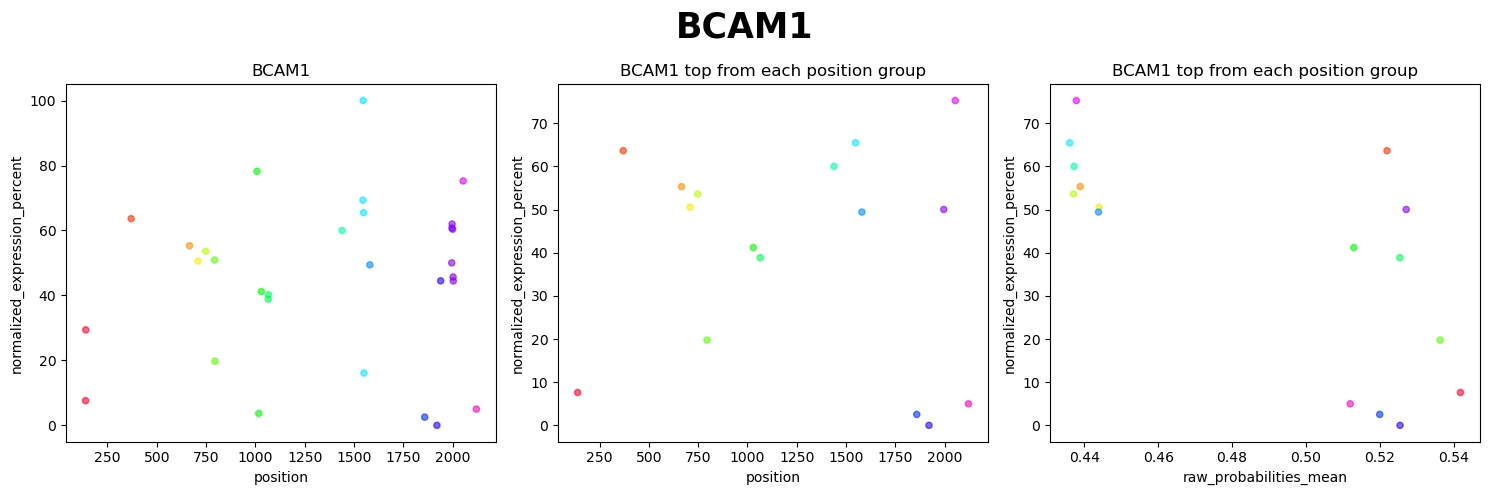

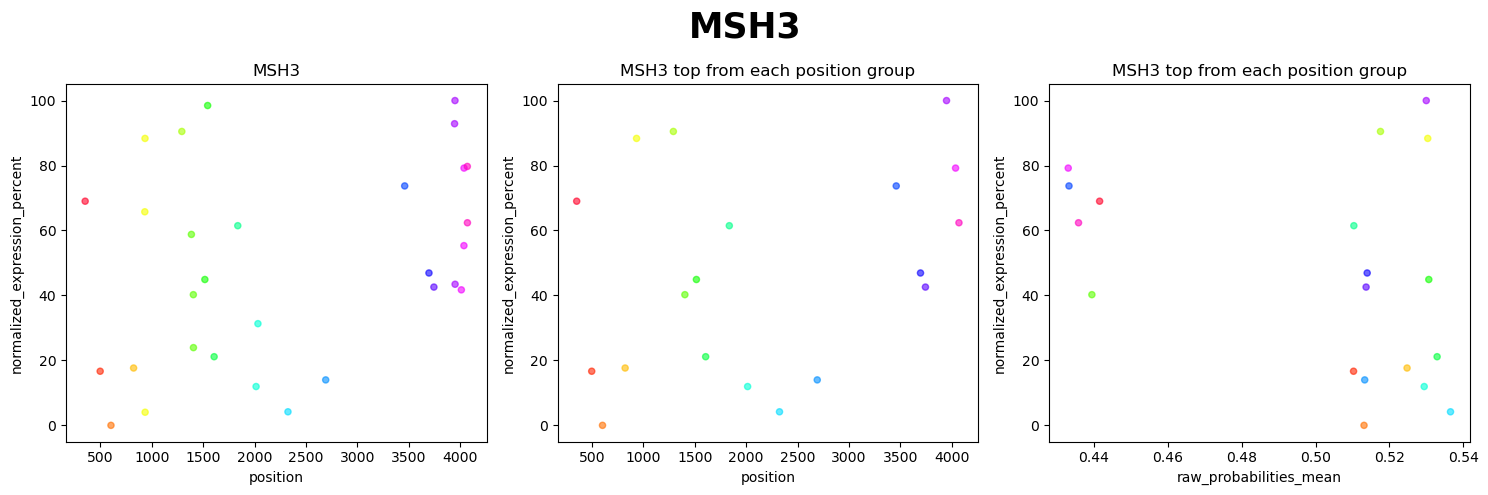

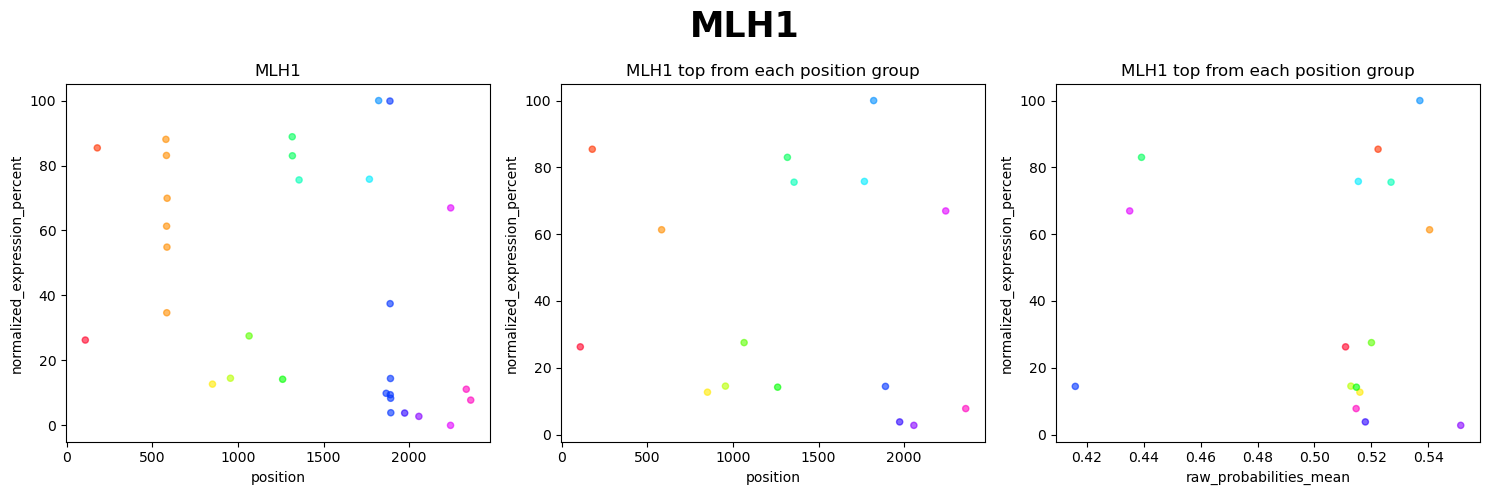

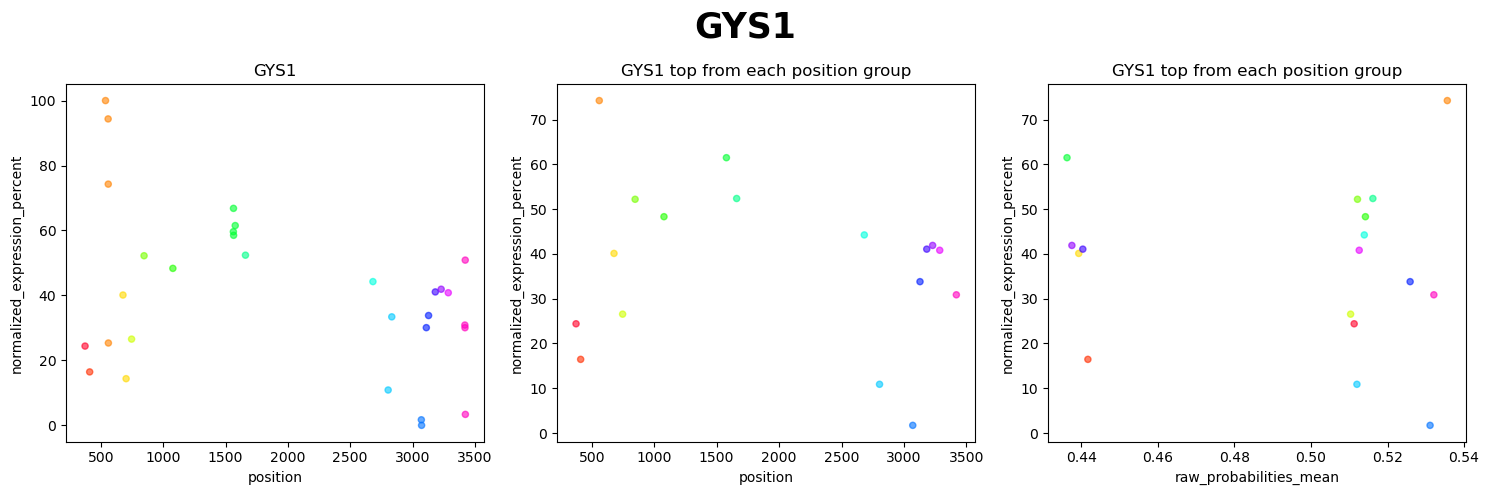

In [1191]:
for df_gene__ in [df_bcam1, df_msh3, df_mlh1, df_gys1]:
    gene_name_= df_gene__.at[0,'gene']
    df_gene_ = df_gene__.copy()


    fig,axs = plt.subplots(1,3)
    fig.set_size_inches(w=15,h=5)

    
    df_gene_.sort_values(by='position',inplace=True)
    df_gene_.reset_index(inplace=True,drop=True)
    df_gene_[['position','raw_probabilities_mean','normalized_expression_percent']]
    
    # Group by position regions
    df_gene_['position']
    
    all_pos_ls = []
    pos_group_dict = {}
    last_pos_group_dict_key_ = 1
    
    for indx_ in df_gene_.index:
        pos_ = df_gene_.at[indx_,'position']
        if len(all_pos_ls) == 0:
            pos_group_dict[last_pos_group_dict_key_] = [pos_]
        else:
            pos_prev_ = all_pos_ls[-1]
            if (pos_-pos_prev_) < 30:#20:
                # same pos_group
                pos_group_dict[last_pos_group_dict_key_]+=[pos_]
            else:
                # different pos_group
                pos_group_dict[last_pos_group_dict_key_+1]=[pos_]
                last_pos_group_dict_key_+=1
        all_pos_ls.append(pos_)
    
    
    cmap_name = 'gist_rainbow'
    num_colors = len(pos_group_dict)
    hex_color_list_gene_pos = colormap_to_hex_list(cmap_name,num_colors)
    hex_color_list_gene_pos
    
    color_ls_gene_pos_groups = []
    ct_ = 0
    for k in pos_group_dict.keys():
        color_ls_gene_pos_groups+=[hex_color_list_gene_pos[ct_]]*len(pos_group_dict[k])
        ct_+=1
    
    
    
    # Plot position groups
    df_gene_.plot.scatter(
            x='position',
            # y='avg_raw_expression_percent',
            y='normalized_expression_percent',
            marker='o',
            alpha=0.6,
            c = color_ls_gene_pos_groups,
            ax=axs[0],
            title=gene_name_.upper(),
    )
    
    # # OLD:
    # ## Pick single siRNA from each group (one with highest score)
    # indx_top_p_per_pos_group_gene_ls = []
    # for k in range(len(pos_group_dict)):
    #     pos_ls = pos_group_dict[k+1]
    #     (df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
    
    #     # print(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
    #     max_p_pos_group_ = max(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
    #     indx_max_p_pos_group_ = df_gene_[df_gene_['position'].isin(pos_ls)][df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'] == max_p_pos_group_].index[0]
    #     # print(df_gene_.at[indx_max_p_pos_group_,'raw_probabilities_mean'])
    #     indx_top_p_per_pos_group_gene_ls.append(indx_max_p_pos_group_)
    #     # print()
    
    # NEW:
    # For each position group, determine if it is a mostly positive prediction group or mostly negative
    # If mostly positive pick single siRNA from group with highest score
    # If mostly negative pick single siRNA from group with lowest score
    indx_top_p_per_pos_group_gene_ls = []
    for k in range(len(pos_group_dict)):
        pos_ls = pos_group_dict[k+1]
        #print(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
    
        #### Determine if mostly positive or mostly negative 
        #print(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'].apply(lambda x: x>=0.5).value_counts().index[0])
        if df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'].apply(lambda x: x>=0.5).value_counts().index[0]:
            max_p_pos_group_ = max(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
            indx_max_p_pos_group_ = df_gene_[df_gene_['position'].isin(pos_ls)][df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'] == max_p_pos_group_].index[0]
            indx_top_p_per_pos_group_gene_ls.append(indx_max_p_pos_group_)
    
        else:
            min_p_pos_group_ = min(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
            indx_min_p_pos_group_ = df_gene_[df_gene_['position'].isin(pos_ls)][df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'] == min_p_pos_group_].index[0]
            indx_top_p_per_pos_group_gene_ls.append(indx_min_p_pos_group_)
    
    
        
    # Plot position groups
    df_gene_.iloc[indx_top_p_per_pos_group_gene_ls].plot.scatter(
            x='position',
            # y='avg_raw_expression_percent',
            y='normalized_expression_percent',
            marker='o',
            alpha=0.6,
            c = hex_color_list_gene_pos,
            ax=axs[1],
            title=gene_name_.upper()+' top from each position group',
    )
    
    # Plot expression vs score
    df_gene_.iloc[indx_top_p_per_pos_group_gene_ls].plot.scatter(
            x='raw_probabilities_mean',
            # y='avg_raw_expression_percent',
            y='normalized_expression_percent',
            marker='o',
            alpha=0.6,
            c = hex_color_list_gene_pos,
            ax=axs[2],
            title=gene_name_.upper()+' top from each position group',
    )
    fig.suptitle(gene_name_.upper(),fontsize=25,fontweight='bold')
    ## Save Figure
    fnm_final_ = gene_name_+'_TRYING-TO-UNBIAS-POSITION_picking_top_10_bottom_10_by_score'
    
    fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
    fig.tight_layout()
    plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
    fig.savefig(fnm_final_dir_+fnm_final_+'.svg',format='svg',transparent=True)
    fig.savefig(fnm_final_dir_+fnm_final_+'.png',format='png',dpi=300,transparent=False)
    print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final_ + '.png\n\t'+ fnm_final_ + '.svg')



# Plot all 4 genes together with selected position group siRNAs

Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	plot_filtered_no_pos_bias_expression-vs-score-per-gene-colored.png
	plot_filtered_no_pos_bias_expression-vs-score-per-gene-colored.svg


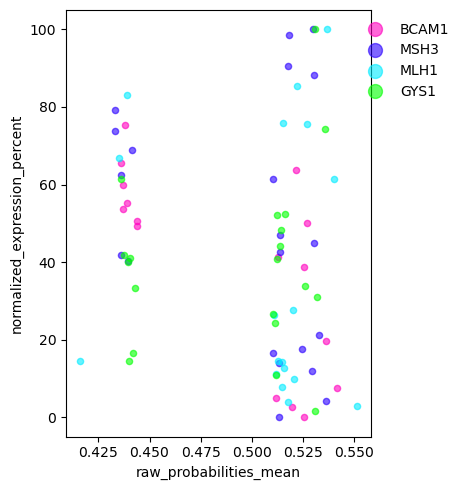

In [1192]:
# Plot expression vs score
fig,ax = plt.subplots()
fig.set_size_inches(w=5,h=5)

cmap_name = 'gist_rainbow'
hex_cols = colormap_to_hex_list(cmap_name,6)[::-1]

gene_colors = ['#FF3400',  '#00C920', '#00c9ff','#9200ff']

# Legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements=[]

ct_=0
for df_gene__ in [df_bcam1, df_msh3, df_mlh1, df_gys1]:
    gene_name_= df_gene__.at[0,'gene']
    df_gene_ = df_gene__.copy()

    
    
    df_gene_.sort_values(by='position',inplace=True)
    df_gene_.reset_index(inplace=True,drop=True)
    df_gene_[['position','raw_probabilities_mean','normalized_expression_percent']]
    
    # Group by position regions
    df_gene_['position']
    
    all_pos_ls = []
    pos_group_dict = {}
    last_pos_group_dict_key_ = 1
    
    for indx_ in df_gene_.index:
        pos_ = df_gene_.at[indx_,'position']
        if len(all_pos_ls) == 0:
            pos_group_dict[last_pos_group_dict_key_] = [pos_]
        else:
            pos_prev_ = all_pos_ls[-1]
            if (pos_-pos_prev_) < 20:
                # same pos_group
                pos_group_dict[last_pos_group_dict_key_]+=[pos_]
            else:
                # different pos_group
                pos_group_dict[last_pos_group_dict_key_+1]=[pos_]
                last_pos_group_dict_key_+=1
        all_pos_ls.append(pos_)
    

    # NEW:
    # For each position group, determine if it is a mostly positive prediction group or mostly negative
    # If mostly positive pick single siRNA from group with highest score
    # If mostly negative pick single siRNA from group with lowest score
    indx_top_p_per_pos_group_gene_ls = []
    for k in range(len(pos_group_dict)):
        pos_ls = pos_group_dict[k+1]
        #print(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
    
        #### Determine if mostly positive or mostly negative 
        #print(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'].apply(lambda x: x>=0.5).value_counts().index[0])
        if df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'].apply(lambda x: x>=0.5).value_counts().index[0]:
            max_p_pos_group_ = max(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
            indx_max_p_pos_group_ = df_gene_[df_gene_['position'].isin(pos_ls)][df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'] == max_p_pos_group_].index[0]
            indx_top_p_per_pos_group_gene_ls.append(indx_max_p_pos_group_)
    
        else:
            min_p_pos_group_ = min(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
            indx_min_p_pos_group_ = df_gene_[df_gene_['position'].isin(pos_ls)][df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'] == min_p_pos_group_].index[0]
            indx_top_p_per_pos_group_gene_ls.append(indx_min_p_pos_group_)

    df_gene_.iloc[indx_top_p_per_pos_group_gene_ls].plot.scatter(
        x='raw_probabilities_mean',
        # y='avg_raw_expression_percent',
        y='normalized_expression_percent',
        marker='o',
        alpha=0.6,
        c = hex_cols[ct_],
        ax=ax,
        # title='msh3'.upper()+' top from each position group',
    )

    legend_elements.append(
        Line2D([0],[0],marker='o',color=hex_cols[ct_],linestyle='None',markersize=10,
               label=gene_name_,alpha=0.6),
    )
    
    ct_+=1
    
ax.legend(handles=legend_elements,loc='upper right',frameon=False,fontsize=10,bbox_to_anchor=(1.3, 1.0))
    


## Save Figure
fnm_final_ = 'plot_filtered_no_pos_bias_expression-vs-score-per-gene-colored'

fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
fig.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
fig.savefig(fnm_final_dir_+fnm_final_+'.svg',format='svg',transparent=True)
fig.savefig(fnm_final_dir_+fnm_final_+'.png',format='png',dpi=300,transparent=False)
print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final_ + '.png\n\t'+ fnm_final_ + '.svg')



## Create dataframe of just these oligos compiled together for all 4 genes

75 120


<AxesSubplot:xlabel='raw_probabilities_mean', ylabel='normalized_expression_percent'>

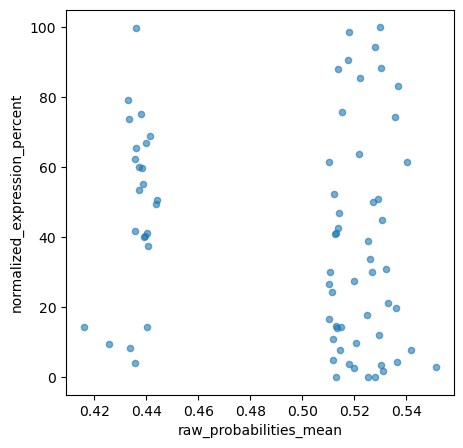

In [1193]:
indx_top_p_per_pos_group_gene_ls_dict = {}
for df_gene__ in [df_bcam1, df_msh3, df_mlh1, df_gys1]:
    gene_name_= df_gene__.at[0,'gene']
    df_gene_ = df_gene__.copy()

    
    
    df_gene_.sort_values(by='position',inplace=True)
    df_gene_.reset_index(inplace=True,drop=True)
    df_gene_[['position','raw_probabilities_mean','normalized_expression_percent']]
    
    # Group by position regions
    df_gene_['position']
    
    all_pos_ls = []
    pos_group_dict = {}
    last_pos_group_dict_key_ = 1
    
    for indx_ in df_gene_.index:
        pos_ = df_gene_.at[indx_,'position']
        if len(all_pos_ls) == 0:
            pos_group_dict[last_pos_group_dict_key_] = [pos_]
        else:
            pos_prev_ = all_pos_ls[-1]
            if (pos_-pos_prev_) < 20:
                # same pos_group
                pos_group_dict[last_pos_group_dict_key_]+=[pos_]
            else:
                # different pos_group
                pos_group_dict[last_pos_group_dict_key_+1]=[pos_]
                last_pos_group_dict_key_+=1
        all_pos_ls.append(pos_)
    

    # NEW:
    # For each position group, determine if it is a mostly positive prediction group or mostly negative
    # If mostly positive pick single siRNA from group with highest score
    # If mostly negative pick single siRNA from group with lowest score
    indx_top_p_per_pos_group_gene_ls = []
    for k in range(len(pos_group_dict)):
        pos_ls = pos_group_dict[k+1]
        #print(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
    
        #### Determine if mostly positive or mostly negative 
        #print(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'].apply(lambda x: x>=0.5).value_counts().index[0])
        if df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'].apply(lambda x: x>=0.5).value_counts().index[0]:
            max_p_pos_group_ = max(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
            indx_max_p_pos_group_ = df_gene_[df_gene_['position'].isin(pos_ls)][df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'] == max_p_pos_group_].index[0]
            indx_top_p_per_pos_group_gene_ls.append(indx_max_p_pos_group_)
    
        else:
            min_p_pos_group_ = min(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
            indx_min_p_pos_group_ = df_gene_[df_gene_['position'].isin(pos_ls)][df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'] == min_p_pos_group_].index[0]
            indx_top_p_per_pos_group_gene_ls.append(indx_min_p_pos_group_)


    indx_top_p_per_pos_group_gene_ls_dict[gene_name_] = indx_top_p_per_pos_group_gene_ls


top_sirnas_per_pos_group = (
    list(df_bcam1.iloc[indx_top_p_per_pos_group_gene_ls_dict['BCAM1']]['oligo'])+
    list(df_mlh1.iloc[indx_top_p_per_pos_group_gene_ls_dict['MLH1']]['oligo'])+
    list(df_msh3.iloc[indx_top_p_per_pos_group_gene_ls_dict['MSH3']]['oligo'])+
    list(df_gys1.iloc[indx_top_p_per_pos_group_gene_ls_dict['GYS1']]['oligo']))

print(len(top_sirnas_per_pos_group),len(df))

df_top_pos_group = df[df['oligo'].isin(top_sirnas_per_pos_group)].copy()

df_top_pos_group

# Plot expression vs score
fig,ax = plt.subplots()
fig.set_size_inches(w=5,h=5)

df_top_pos_group.plot.scatter(
        x='raw_probabilities_mean',
        # y='avg_raw_expression_percent',
        y='normalized_expression_percent',
        marker='o',
        alpha=0.6,
        # c = hex_cols[0],
        ax=ax,
        # title='msh3'.upper()+' top from each position group',
)


In [1197]:
df_top_pos_group['gene'].value_counts()

MSH3     21
GYS1     20
MLH1     18
BCAM1    16
Name: gene, dtype: int64

## Remove old score data - is likely just adding noise

<AxesSubplot:xlabel='raw_probabilities_mean', ylabel='normalized_expression_percent'>

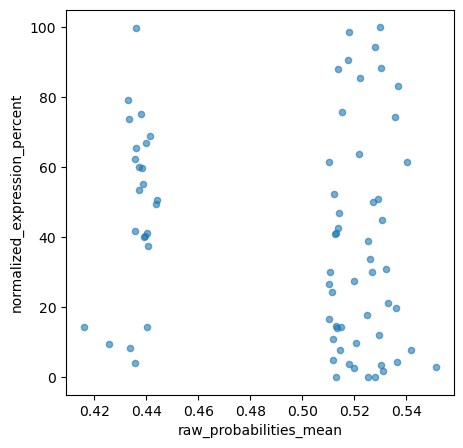

In [1194]:
# Plot expression vs score
fig,ax = plt.subplots()
fig.set_size_inches(w=5,h=5)

df_top_pos_group[df_top_pos_group['old_screen_or_new'] == 'new'].plot.scatter(
        x='raw_probabilities_mean',
        # y='avg_raw_expression_percent',
        y='normalized_expression_percent',
        marker='o',
        alpha=0.6,
        # c = hex_cols[0],
        ax=ax,
        # title='msh3'.upper()+' top from each position group',
)


## Plot Confusion Matrix for compiled top picked siRNAs

Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	confusion_matrix_filtered_no_pos_bias.png
	confusion_matrix_filtered_no_pos_bias.svg


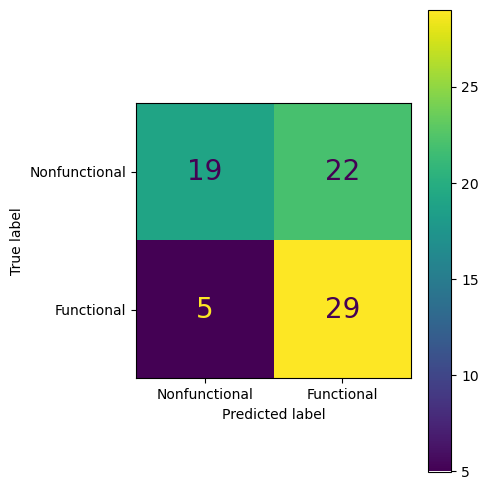

In [1195]:
fig,ax = plt.subplots()
fig.set_size_inches(w=5,h=5)

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

# TODO: recompute confusion matrix

cm = confusion_matrix(
    df_top_pos_group['normalized_expression_percent'].apply(lambda x: x <= 35),
    #df_top_pos_group['avg_raw_expression_percent'].apply(lambda x: x <= 25),

    df_top_pos_group['raw_probabilities_mean'].apply(lambda x: x >= 0.5) )

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Nonfunctional","Functional"])
disp.plot(ax=ax)

for txt in ax.texts:
    txt.set_fontsize(20)
# ax.set_title(sc_.split('_')[0]+" Score Predictions\n("+str(len(df_old_new[ (df_old_new['old_screen_or_new'] == 'old')]))+' siRNAs)',fontweight='bold')

## Save Figure
fnm_final_ = 'confusion_matrix_filtered_no_pos_bias'

fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
fig.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
fig.savefig(fnm_final_dir_+fnm_final_+'.svg',format='svg',transparent=True)
fig.savefig(fnm_final_dir_+fnm_final_+'.png',format='png',dpi=300,transparent=False)
print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final_ + '.png\n\t'+ fnm_final_ + '.svg')




# Compute F1 Score for compiled top picked siRNAs

In [1196]:
import numpy as np
from sklearn.metrics import f1_score
# y_true = [0, 1, 2, 0, 1, 2]
# y_pred = [0, 2, 1, 0, 0, 1]

y_true = df_top_pos_group['actually_functional']
y_pred = df_top_pos_group['raw_probabilities_mean'].apply(lambda x: x >= 0.5) 


f1_macro_ = np.round(f1_score(y_true, y_pred, average='macro'),3)
f1_micro_ = np.round(f1_score(y_true, y_pred, average='micro'),3)
f1_weighted_ = np.round(f1_score(y_true, y_pred, average='weighted'),3)
f1_binary_ = np.round(f1_score(y_true, y_pred, average='binary'),3)

print('\nF-1:')
print(
    ' '+str(f1_macro_),'\n',
    f1_micro_,'\n',
    f1_weighted_,'\n',
    f1_binary_,'\n')

import numpy as np
from sklearn.metrics import fbeta_score
beta_ = 0.25

fbeta_macro_ = np.round(fbeta_score(y_true, y_pred, average='macro', beta=beta_),3)
fbeta_micro_ = np.round(fbeta_score(y_true, y_pred, average='micro', beta=beta_),3)
fbeta_weighted_ = np.round(fbeta_score(y_true, y_pred, average='weighted', beta=beta_),3)
fbeta_binary_ = np.round(fbeta_score(y_true, y_pred, average='binary', beta=beta_),3)

print('\nF-beta ('+str(beta_)+'):')
print(
    ' '+str(fbeta_macro_),'\n',
    fbeta_micro_,'\n',
    fbeta_weighted_,'\n',
    fbeta_binary_,'\n')



F-1:
 0.633 
 0.64 
 0.629 
 0.682 


F-beta (0.25):
 0.67 
 0.64 
 0.678 
 0.58 



# Try Random Sampling/Statistical Boosting

* ## Select from ALL prediction scores 100 randomly
* ## Then from there keep only those that have been screened
* ## Then generate an F1 score from this
* ## Repeat multiple times


### *Will help tell us how much the regional/positional bias is affecting the scoring.*

### [top](#top) | [bottom](#bottom)

## Load in all designs
## Make Random Selections

In [167]:
# select 100 random scores out of all designs
df_all = pd.read_csv('all_ssrf_scored_designs_msh3_gys1_mlh1_bcam1.csv')
df_all

# MSH3: NM_002439: 4443nts
# GYS1: NM_001161587
# MLH1: XM_005265161

df_all['oligo'] = df_all.apply(lambda x: x['gene']+'_'+str(x['Oligo_position']), axis=1)
display(df_all)


num_rounds = 10
num_to_select = 200
import random
print("When select "+str(num_to_select)+' randomly out of all possible '+str(len(df_all))+' scored siRNAs')
# select X randomly
for round_ in range(num_rounds):
    rand_sirnas = random.sample(list(df_all.index), num_to_select)
    
    # print(rand_sirnas)
    # print(len(rand_sirnas))
    
    # count number of selected that we have actual data for
    
    try:
        print(str(df_all.iloc[rand_sirnas]['oligo'].isin(df['oligo']).value_counts()[True])+' siRNAs that were screend')
    except:
        print('0 siRNAs that were screend')


    

,Oligo_position,Oligo_ID,Target_Region_Sequence_20mer,Gene_region,GC_content,Revcomp_Guide,Oligo_ID_sense,Oligo_ID_antisense,Score,Region,...,raw_prob_preds_7,raw_prob_preds_8,raw_prob_preds_9,raw_prob_preds_10,raw_probabilities_mean,raw_probabilities_std,raw_probabilities_aver,raw_probabilities_max,raw_probabilities_min,oligo
0,2057,MLH1_XM_005265161_2057,UCAGUAAAGAAUGCGCUAUG,AATGTTTTGAAAGCCTCAGTAAAGAATGCGCTATGTTCTATTCCA,40,CAUAGCGCAUUCUUUACUGA,MLH1_XM_005265161_2057_s,MLH1_XM_005265161_2057_as,133,ORF,...,0.534026,0.537983,0.568142,0.538343,0.551441,0.015495,0.551441,0.569503,0.525951,MLH1_2057
1,139,BCAM_NM_00000000_139,GCUGGUGGAGGUGAUGCGAG,CTTGTCTGTACCCCCGCTGGTGGAGGTGATGCGAGGAAAGTCTGT,65,CUCGCAUCACCUCCACCAGC,BCAM_NM_00000000_139_s,BCAM_NM_00000000_139_as,34,NaN,...,0.536857,0.549759,0.533108,0.552188,0.541744,0.009811,0.541744,0.552392,0.519491,BCAM_139
2,583,MLH1_XM_005265161_583,GUACACAAUGCAGGCAUUAG,GTTGGCAGGTATTCAGTACACAATGCAGGCATTAGTTTCTCAGTT,45,CUAAUGCCUGCAUUGUGUAC,MLH1_XM_005265161_583_s,MLH1_XM_005265161_583_as,67,ORF,...,0.507185,0.558606,0.542799,0.543109,0.540495,0.015281,0.540495,0.558606,0.507185,MLH1_583
3,584,MLH1_XM_005265161_584,UACACAAUGCAGGCAUUAGU,TTGGCAGGTATTCAGTACACAATGCAGGCATTAGTTTCTCAGTTA,40,ACUAAUGCCUGCAUUGUGUA,MLH1_XM_005265161_584_s,MLH1_XM_005265161_584_as,121,ORF,...,0.539265,0.550932,0.525023,0.547155,0.539374,0.017883,0.539374,0.579563,0.508288,MLH1_584
4,1822,MLH1_XM_005265161_1822,ACAGAGGAAGAUGGUCCCAA,CCAGAGAGTGGCTGGACAGAGGAAGATGGTCCCAAAGAAGGACTT,50,UUGGGACCAUCUUCCUCUGU,MLH1_XM_005265161_1822_s,MLH1_XM_005265161_1822_as,20,ORF,...,0.561365,0.534383,0.534370,0.519792,0.537076,0.011355,0.537076,0.561365,0.519792,MLH1_1822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9323,3813,MSH3_NM_002439_3813,UUUUUAUUUGUUUCAGUUCA,AAAATTTACTTGATATTTTTATTTGTTTCAGTTCAGATAATTGGC,20,UGAACUGAAACAAAUAAAAA,MSH3_NM_002439_3813_s,MSH3_NM_002439_3813_as,27,3UTR,...,0.463809,0.463187,0.457249,0.441039,0.461763,0.011500,0.461763,0.474416,0.441039,MSH3_3813
9324,154,MSH3_NM_002439_154,AUUCUUCCAGUCUACGGGAA,AGCGGTTTTGAGCCGATTCTTCCAGTCTACGGGAAGCCTGAAATC,45,UUCCCGUAGACUGGAAGAAU,MSH3_NM_002439_154_s,MSH3_NM_002439_154_as,-19,ORF,...,0.499725,0.482829,0.459914,0.472861,0.471676,0.012409,0.471676,0.499725,0.452847,MSH3_154
9325,2233,MSH3_NM_002439_2233,UCAAGGUGUUAUUGACGAGA,GAGGAAGGATGAAATTCAAGGTGTTATTGACGAGATCCGAATGCA,40,UCUCGUCAAUAACACCUUGA,MSH3_NM_002439_2233_s,MSH3_NM_002439_2233_as,21,ORF,...,0.497953,0.445332,0.482948,0.510923,0.483938,0.017515,0.483938,0.510923,0.445332,MSH3_2233
9326,156,MSH3_NM_002439_156,UCUUCCAGUCUACGGGAAGC,CGGTTTTGAGCCGATTCTTCCAGTCTACGGGAAGCCTGAAATCCA,55,GCUUCCCGUAGACUGGAAGA,MSH3_NM_002439_156_s,MSH3_NM_002439_156_as,97,ORF,...,0.507113,0.490302,0.501773,0.465218,0.485325,0.015845,0.485325,0.507113,0.458515,MSH3_156


When select 200 randomly out of all possible 9328 scored siRNAs
2 siRNAs that were screend
3 siRNAs that were screend
2 siRNAs that were screend
3 siRNAs that were screend
0 siRNAs that were screend
2 siRNAs that were screend
3 siRNAs that were screend
2 siRNAs that were screend
3 siRNAs that were screend
3 siRNAs that were screend


When select 200 randomly out of all possible 9328 scored siRNAs
3 siRNAs that were screend
2 siRNAs that were screend
3 siRNAs that were screend
2 siRNAs that were screend
2 siRNAs that were screend
3 siRNAs that were screend
2 siRNAs that were screend
4 siRNAs that were screend
0 siRNAs that were screend
0 siRNAs that were screend


## This method of selection will not work, because so few will have been screened

# Try a different method for selection randomly

## Randomly pick a subset of the screened data and pick between X%-Y% each round

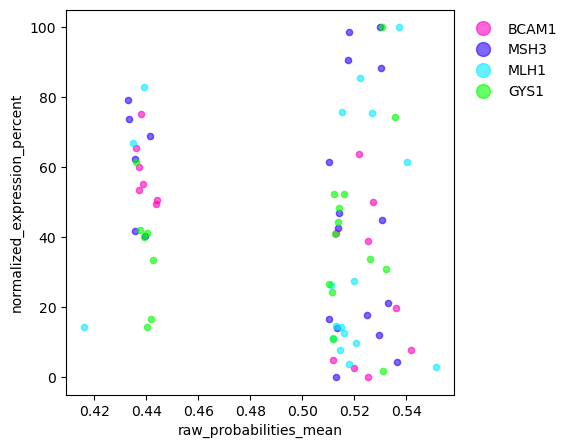

In [283]:
# Plot expression vs score
fig,ax = plt.subplots()
fig.set_size_inches(w=5,h=5)

cmap_name = 'gist_rainbow'
hex_cols = colormap_to_hex_list(cmap_name,6)[::-1]

gene_colors = ['#FF3400',  '#00C920', '#00c9ff','#9200ff']

# Legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements=[]

ct_=0
for df_gene__ in [df_bcam1, df_msh3, df_mlh1, df_gys1]:
    gene_name_= df_gene__.at[0,'gene']
    df_gene_ = df_gene__.copy()

    
    
    df_gene_.sort_values(by='position',inplace=True)
    df_gene_.reset_index(inplace=True,drop=True)
    df_gene_[['position','raw_probabilities_mean','normalized_expression_percent']]
    
    # Group by position regions
    df_gene_['position']
    
    all_pos_ls = []
    pos_group_dict = {}
    last_pos_group_dict_key_ = 1
    
    for indx_ in df_gene_.index:
        pos_ = df_gene_.at[indx_,'position']
        if len(all_pos_ls) == 0:
            pos_group_dict[last_pos_group_dict_key_] = [pos_]
        else:
            pos_prev_ = all_pos_ls[-1]
            if (pos_-pos_prev_) < 20:
                # same pos_group
                pos_group_dict[last_pos_group_dict_key_]+=[pos_]
            else:
                # different pos_group
                pos_group_dict[last_pos_group_dict_key_+1]=[pos_]
                last_pos_group_dict_key_+=1
        all_pos_ls.append(pos_)
    

    # NEW:
    # For each position group, determine if it is a mostly positive prediction group or mostly negative
    # If mostly positive pick single siRNA from group with highest score
    # If mostly negative pick single siRNA from group with lowest score
    indx_top_p_per_pos_group_gene_ls = []
    for k in range(len(pos_group_dict)):
        pos_ls = pos_group_dict[k+1]
        #print(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
    
        #### Determine if mostly positive or mostly negative 
        #print(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'].apply(lambda x: x>=0.5).value_counts().index[0])
        if df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'].apply(lambda x: x>=0.5).value_counts().index[0]:
            max_p_pos_group_ = max(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
            indx_max_p_pos_group_ = df_gene_[df_gene_['position'].isin(pos_ls)][df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'] == max_p_pos_group_].index[0]
            indx_top_p_per_pos_group_gene_ls.append(indx_max_p_pos_group_)
    
        else:
            min_p_pos_group_ = min(df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'])
            indx_min_p_pos_group_ = df_gene_[df_gene_['position'].isin(pos_ls)][df_gene_[df_gene_['position'].isin(pos_ls)]['raw_probabilities_mean'] == min_p_pos_group_].index[0]
            indx_top_p_per_pos_group_gene_ls.append(indx_min_p_pos_group_)

    df_gene_.iloc[indx_top_p_per_pos_group_gene_ls].plot.scatter(
        x='raw_probabilities_mean',
        # y='avg_raw_expression_percent',
        y='normalized_expression_percent',
        marker='o',
        alpha=0.6,
        c = hex_cols[ct_],
        ax=ax,
        # title='msh3'.upper()+' top from each position group',
    )

    legend_elements.append(
        Line2D([0],[0],marker='o',color=hex_cols[ct_],linestyle='None',markersize=10,
               label=gene_name_,alpha=0.6),
    )
    
    ct_+=1
    
ax.legend(handles=legend_elements,loc='upper right',frameon=False,fontsize=10,bbox_to_anchor=(1.3, 1.0))
    


# ## Save Figure
# fnm_final_ = 'plot_filtered_no_pos_bias_expression-vs-score'

# fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
# fig.tight_layout()
# plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
# fig.savefig(fnm_final_dir_+fnm_final_+'.svg',format='svg',transparent=True)
# fig.savefig(fnm_final_dir_+fnm_final_+'.png',format='png',dpi=300,transparent=False)
# print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final_ + '.png\n\t'+ fnm_final_ + '.svg')



Sample size per round
min size: 30 	max size: 42 	total: 120
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	25_rounds_30-to-42_random_sampling_confusion_matrix_filtered_no_pos_bias.png
	25_rounds_30-to-42_random_sampling_confusion_matrix_filtered_no_pos_bias.svg
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	25_rounds_30-to-42_random_sampling_expression-vs-prob-score_filtered_no_pos_bias.png
	25_rounds_30-to-42_random_sampling_expression-vs-prob-score_filtered_no_pos_bias.svg


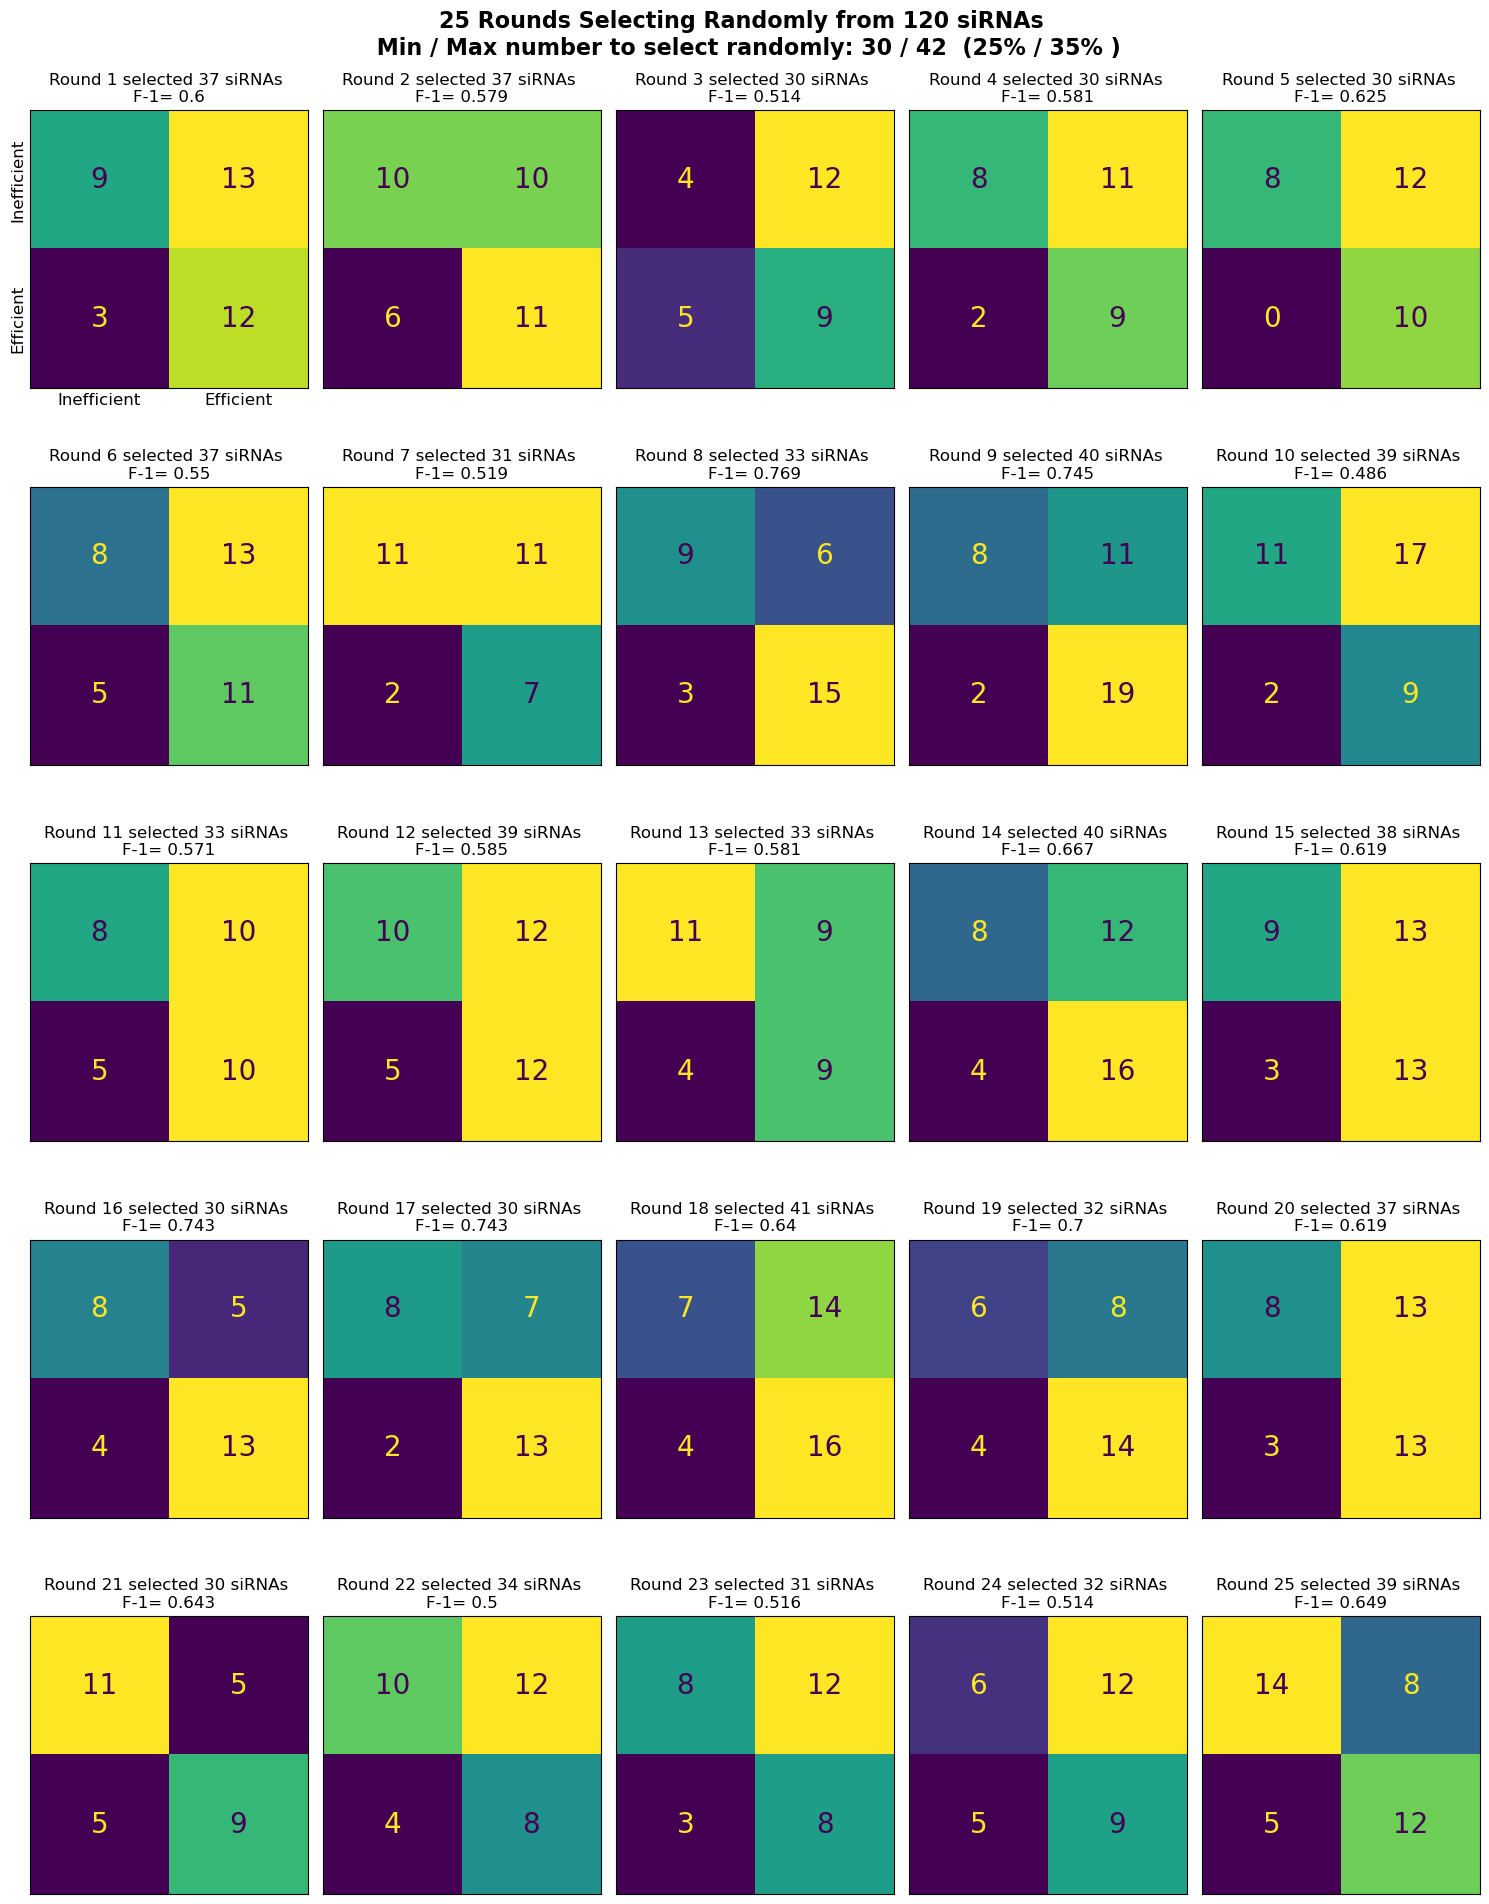

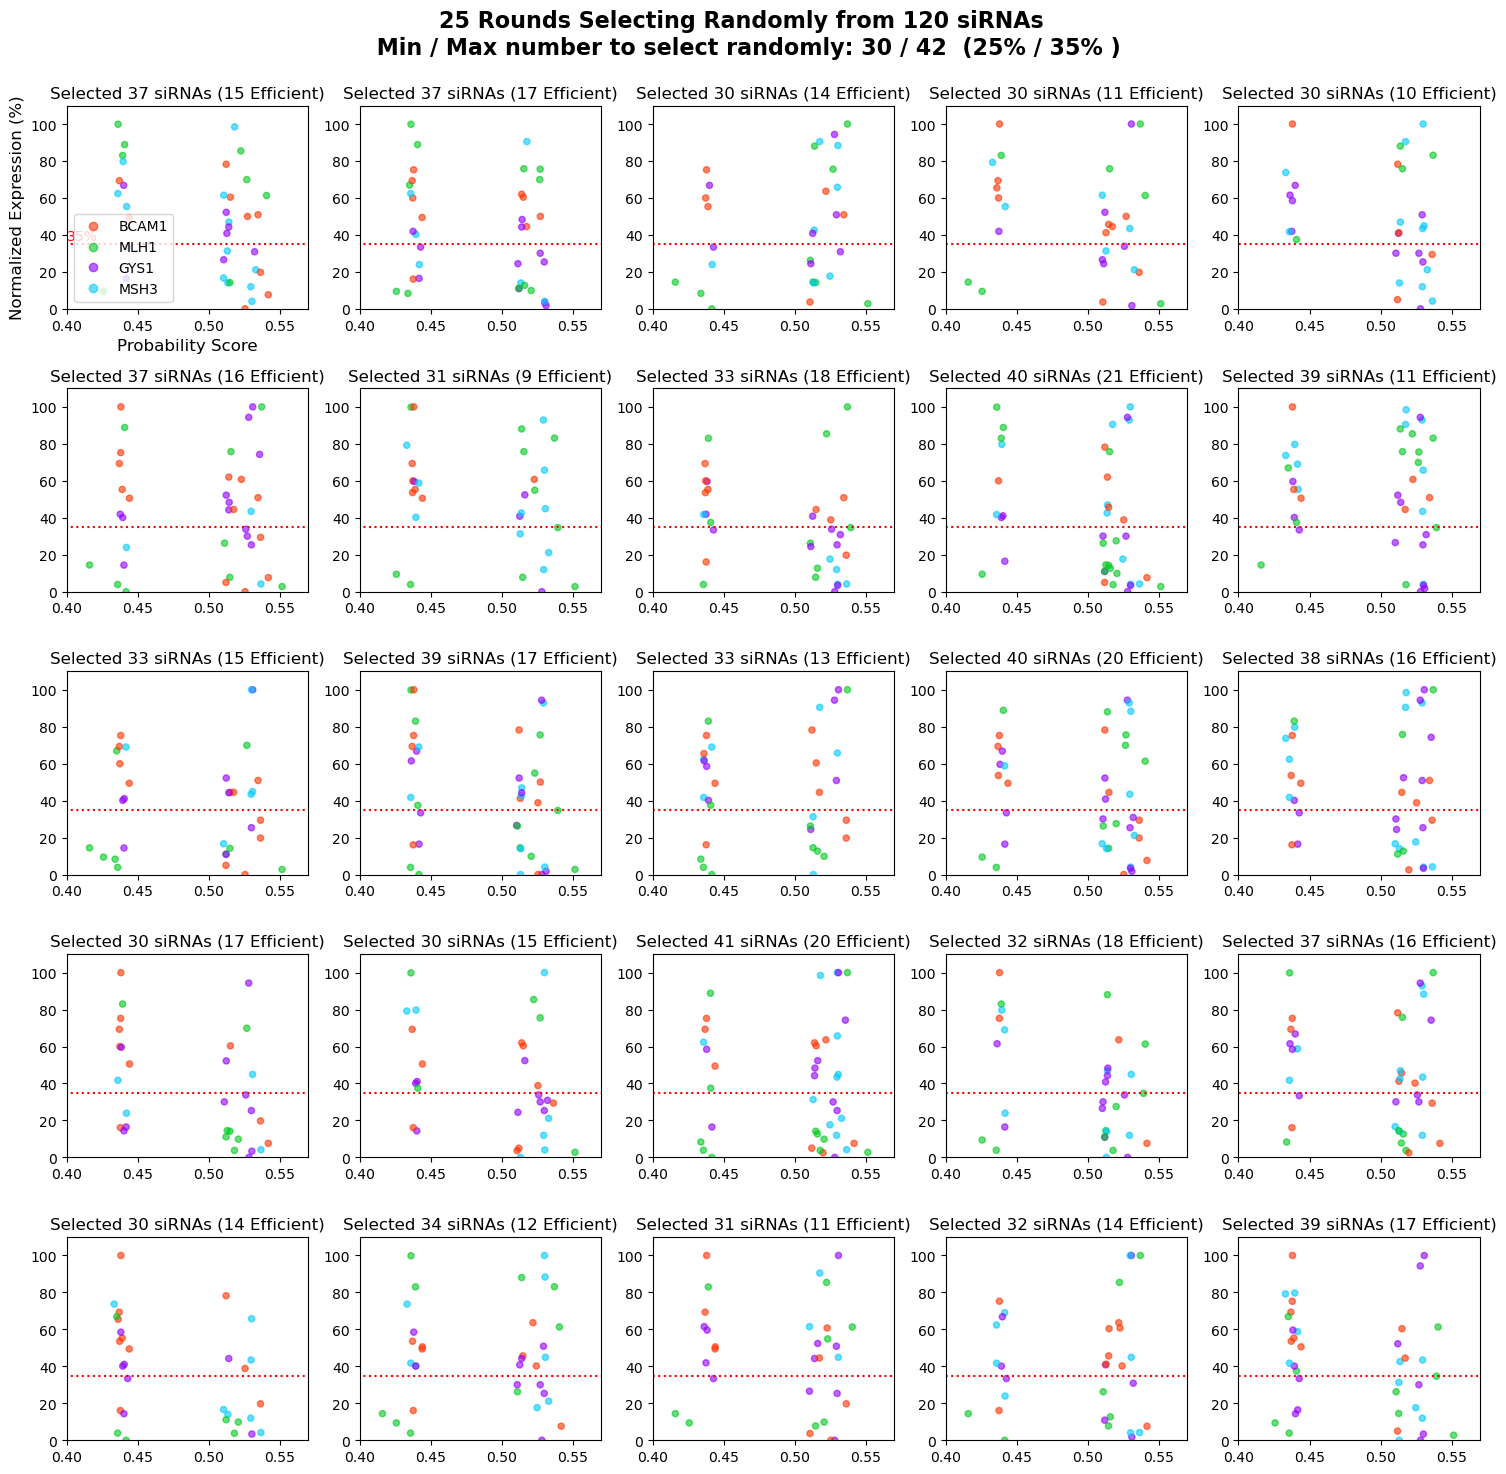

In [432]:
min_size = int(len(df)*.25)
max_size = int(len(df)*.35)
num_rounds_ = 25



min_size_pcnt = int(np.round(100*(min_size/len(df)),0))
max_size_pcnt = int(np.round(100*(max_size/len(df)),0))
df.reset_index(inplace=True,drop=True)
import random
import math
range_rand_size = list(range(min_size,max_size+1))  



gene_color_dict = {
    'BCAM1' : '#FF3400',
    'MLH1'  : '#00C920',
    'MSH3'  : '#00c9ff',
    'GYS1'  : '#9200ff'
}

ncols_ = 5
fig_cm,axs_cm = plt.subplots(math.ceil(num_rounds_/ncols_),ncols_)
fig_cm.set_size_inches(w=15,h=20)
fig_ex,axs_ex = plt.subplots(math.ceil(num_rounds_/ncols_),ncols_)
fig_ex.set_size_inches(w=15,h=15)

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

print('Sample size per round\nmin size:',min_size,'\tmax size:',max_size,'\ttotal:',len(df))

rand_selections_ls = []
cm_rand_selection_ls = []
f1_ls = []
fbeta_ls = []
for round_ct_ in range(num_rounds_):
    size_round_ = random.sample(range_rand_size, 1)[0]
    #print('Round '+str(round_ct_+1)+' size:',size_round_)
    
    # select size_round_ siRNAs randomly
    rand_sirnas = random.sample(list(df.index), size_round_)
    #display(df.iloc[rand_sirnas])



    rand_selections_ls.append(rand_sirnas)
    
    # Compute F1 scores for selection
    y_true = df.iloc[rand_sirnas]['actually_functional']
    y_pred = df.iloc[rand_sirnas]['raw_probabilities_mean'].apply(lambda x: x >= 0.5) 
    
    f1_macro_ = np.round(f1_score(y_true, y_pred, average='macro'),3)
    f1_micro_ = np.round(f1_score(y_true, y_pred, average='micro'),3)
    f1_weighted_ = np.round(f1_score(y_true, y_pred, average='weighted'),3)
    f1_binary_ = np.round(f1_score(y_true, y_pred, average='binary'),3)
    
    beta_ = 0.25
    
    fbeta_macro_ = np.round(fbeta_score(y_true, y_pred, average='macro', beta=beta_),3)
    fbeta_micro_ = np.round(fbeta_score(y_true, y_pred, average='micro', beta=beta_),3)
    fbeta_weighted_ = np.round(fbeta_score(y_true, y_pred, average='weighted', beta=beta_),3)
    fbeta_binary_ = np.round(fbeta_score(y_true, y_pred, average='binary', beta=beta_),3)
    
    fbeta_ls.append(fbeta_binary_)
    f1_ls.append(f1_binary_)
    
    
    
    
    # Plot Confusion Matrix
    ax_cm = axs_cm[int(round_ct_/ncols_),round_ct_%ncols_]

    cm = confusion_matrix(
        df.iloc[rand_sirnas]['normalized_expression_percent'].apply(lambda x: x <= 35),
        df.iloc[rand_sirnas]['raw_probabilities_mean'].apply(lambda x: x >= 0.5))

    cm_rand_selection_ls.append(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Nonfunctional","Functional"])
    disp.plot(ax=ax_cm,colorbar=False)
    
    for txt in ax_cm.texts:
        txt.set_fontsize(20)
        
    ax_cm.set_ylabel('')
    ax_cm.set_xlabel('')
    ax_cm.tick_params(axis=u'both', which=u'both',length=0)

    if round_ct_ == 0:
        ax_cm.set_yticklabels(['Inefficient','Efficient'],rotation=90,fontsize=12,fontdict={'horizontalalignment':'right','verticalalignment':'center'})
        ax_cm.set_xticklabels(['Inefficient','Efficient'],rotation=0,fontsize=12)
    else:
        ax_cm.set_yticklabels([])
        ax_cm.set_xticklabels([])
    ax_cm.set_title('Round '+str(round_ct_+1)+' selected '+str(size_round_)+' siRNAs \nF-1= '+str(f1_binary_))#+' ('+str(fbeta_binary_)+')')



    
    num_ineff_ = df.iloc[rand_sirnas]['normalized_expression_percent'].apply(lambda x: x<=35).value_counts()[False]
    num_eff_ = len(rand_sirnas)-num_ineff_


    # Plot Expression vs. Probabilities
    ax_ex = axs_ex[int(round_ct_/ncols_),round_ct_%ncols_]
    cols_by_gene = df.iloc[rand_sirnas]['gene'].apply(lambda x: gene_color_dict[x])

    df.iloc[rand_sirnas].plot.scatter(
        x='raw_probabilities_mean',
        # y='avg_raw_expression_percent',
        y='normalized_expression_percent',
        marker='o',
        alpha=0.6,
        c = cols_by_gene,
        ax=ax_ex,
        # title='msh3'.upper()+' top from each position group',
    )

    expr_co_ = 35
    ax_ex.hlines(y=expr_co_, xmin=0, xmax=(max(df[(df['gene'] == gene_)]['position'])), linestyle='dotted',color='red')
    

    # ax_ex.set_title('Round '+str(round_ct_+1)+' selected '+str(size_round_)+' siRNAs \n Efficient = '+str(num_eff_)+' | Inefficient = '+str(num_ineff_))
    ax_ex.set_title('Selected '+str(size_round_)+' siRNAs ('+str(num_eff_)+' Efficient)')

    ax_ex.set_ylim(0,110)
    ax_ex.set_xlim(0.4,0.57)

    if round_ct_ == 0:
        ax_ex.annotate(str(expr_co_)+'%',(0.40,expr_co_+2),color='red')
        legend_elements = [Line2D([0],[0],marker='o',color=gene_color_dict[g],linestyle='None',markersize=6,label=g,alpha=0.6) for g in ['BCAM1', 'MLH1', 'GYS1', 'MSH3']]
        ax_ex.legend(handles=legend_elements,loc='best',frameon=True,fontsize=10)#,bbox_to_anchor=(1.3, 1.0))
        ax_ex.set_ylabel('Normalized Expression (%)',fontsize=12)
        ax_ex.set_xlabel('Probability Score',fontsize=12)
    else:
        ax_ex.set_ylabel('')
        ax_ex.set_xlabel('')

# remove remaining axes from confusion matrix figure
for ct_ in range(len(axs_cm[0])*len(axs_cm)):
    if axs_cm[int(ct_/ncols_),ct_%ncols_].get_title() == '':
        axs_cm[int(ct_/ncols_),ct_%ncols_].remove()

fig_cm.suptitle((str(num_rounds_)+' Rounds Selecting Randomly from '+str(len(df))+' siRNAs \n Min / Max number to select randomly: '+str(min_size)+' / '+str(max_size) +'  ('+str(min_size_pcnt)+'% / '+str(max_size_pcnt)+'% )'),
            fontsize=16,fontweight='bold')
fig_cm.tight_layout()



# remove remaining axes from confusion matrix figure
for ct_ in range(len(axs_ex[0])*len(axs_ex)):
    if axs_ex[int(ct_/ncols_),ct_%ncols_].get_title() == '':
        axs_ex[int(ct_/ncols_),ct_%ncols_].remove()

fig_ex.suptitle((str(num_rounds_)+' Rounds Selecting Randomly from '+str(len(df))+' siRNAs \n Min / Max number to select randomly: '+str(min_size)+' / '+str(max_size) +'  ('+str(min_size_pcnt)+'% / '+str(max_size_pcnt)+'% )\n'),
            fontsize=16,fontweight='bold')
fig_ex.tight_layout()



## Save Figures
fnm_final_cm = str(num_rounds_)+'_rounds_'+str(min_size)+'-to-'+str(max_size)+'_random_sampling_confusion_matrix_filtered_no_pos_bias'

fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
fig_cm.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
fig_cm.savefig(fnm_final_dir_+fnm_final_cm+'.svg',format='svg',transparent=True)
fig_cm.savefig(fnm_final_dir_+fnm_final_cm+'.png',format='png',dpi=300,transparent=False)
print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final_cm + '.png\n\t'+ fnm_final_cm + '.svg')
    
## Save Figures
fnm_final_ex = str(num_rounds_)+'_rounds_'+str(min_size)+'-to-'+str(max_size)+'_random_sampling_expression-vs-prob-score_filtered_no_pos_bias'

fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
fig_ex.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
fig_ex.savefig(fnm_final_dir_+fnm_final_ex+'.svg',format='svg',transparent=True)
fig_ex.savefig(fnm_final_dir_+fnm_final_ex+'.png',format='png',dpi=300,transparent=False)
print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final_ex + '.png\n\t'+ fnm_final_ex + '.svg')
    


# Plot all selections together (with error bars)

# F-1 Score max and Min

In [433]:
np.round(np.mean(f1_ls),2),np.max(f1_ls),np.min(f1_ls),np.round(np.std(f1_ls),2)
# fbeta_ls 


(0.61, 0.769, 0.486, 0.08)

[[ 8.72 10.72]
 [ 3.6  11.48]]
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	CUMULATIVE-MATRIX_25_rounds_30-to-42_random_sampling_filtered_no_pos_bias.png
	CUMULATIVE-MATRIX_25_rounds_30-to-42_random_sampling_filtered_no_pos_bias.svg


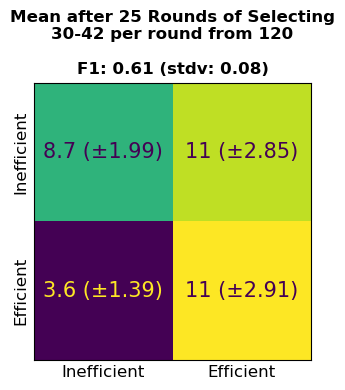

In [434]:
ii_ls=[]
ie_ls=[]
ei_ls=[]
ee_ls=[]

for round_ in range(len(rand_selections_ls)):
    # print(rand_selections_ls[round_])
    ii_ls.append(cm_rand_selection_ls[round_][0][0])
    ie_ls.append(cm_rand_selection_ls[round_][0][1])
    ei_ls.append(cm_rand_selection_ls[round_][1][0])
    ee_ls.append(cm_rand_selection_ls[round_][1][1])



cm_mean = np.array(
    [np.array([np.mean(ii_ls),np.mean(ie_ls)]),
     np.array([np.mean(ei_ls),np.mean(ee_ls)])]
)

cm_std = [np.round(np.std(ii_ls),2),np.round(np.std(ie_ls),2),
          np.round(np.std(ei_ls),2),np.round(np.std(ee_ls),2)]
print(cm_mean)


# Plot Confusion Matrix
fig,ax = plt.subplots()
fig.set_size_inches(w=4,h=4)
# cm = confusion_matrix(
#     df.iloc[rand_sirnas]['normalized_expression_percent'].apply(lambda x: x <= 35),
#     df.iloc[rand_sirnas]['raw_probabilities_mean'].apply(lambda x: x >= 0.5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mean,display_labels=["Nonfunctional","Functional"])
disp.plot(ax=ax,colorbar=False)

for txt,std_ in zip(ax.texts,cm_std):
    txt.set_fontsize(15)
    lab_ = txt.get_text()+' (±'+str(std_)+')'
    txt.set_text(lab_)
    
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis=u'both', which=u'both',length=0)

ax.set_yticklabels(['Inefficient','Efficient'],rotation=90,fontsize=12,fontdict={'horizontalalignment':'right','verticalalignment':'center'})
ax.set_xticklabels(['Inefficient','Efficient'],rotation=0,fontsize=12)

ax.set_title(
    'Mean after '+str(num_rounds_)+' Rounds of Selecting\n'+str(min_size)+'-'+str(max_size)+' per round from '+str(len(df))+(
        '\n\nF1: '+str(np.round(np.mean(f1_ls),2))+' (stdv: '+str(np.round(np.std(f1_ls),2))+')'
    ),
    fontweight='bold')


    
## Save Figures
fnm_final = 'CUMULATIVE-MATRIX_'+str(num_rounds_)+'_rounds_'+str(min_size)+'-to-'+str(max_size)+'_random_sampling_filtered_no_pos_bias'

fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
fig.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
fig.savefig(fnm_final_dir_+fnm_final+'.svg',format='svg',transparent=True)
fig.savefig(fnm_final_dir_+fnm_final+'.png',format='png',dpi=300,transparent=False)
print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final + '.png\n\t'+ fnm_final + '.svg')
    



# Now Redo but Select Certain Number of Predicted Efficient and Inefficient each time`

Sample size per round
min size: 24 	max size: 42 	total: 120
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	PRED-BIASED-25_rounds_24-to-42_random_sampling_confusion_matrix_filtered_no_pos_bias.png
	PRED-BIASED-25_rounds_24-to-42_random_sampling_confusion_matrix_filtered_no_pos_bias.svg
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	PRED-BIASED-25_rounds_24-to-42_random_sampling_expression-vs-prob-score_filtered_no_pos_bias.png
	PRED-BIASED-25_rounds_24-to-42_random_sampling_expression-vs-prob-score_filtered_no_pos_bias.svg


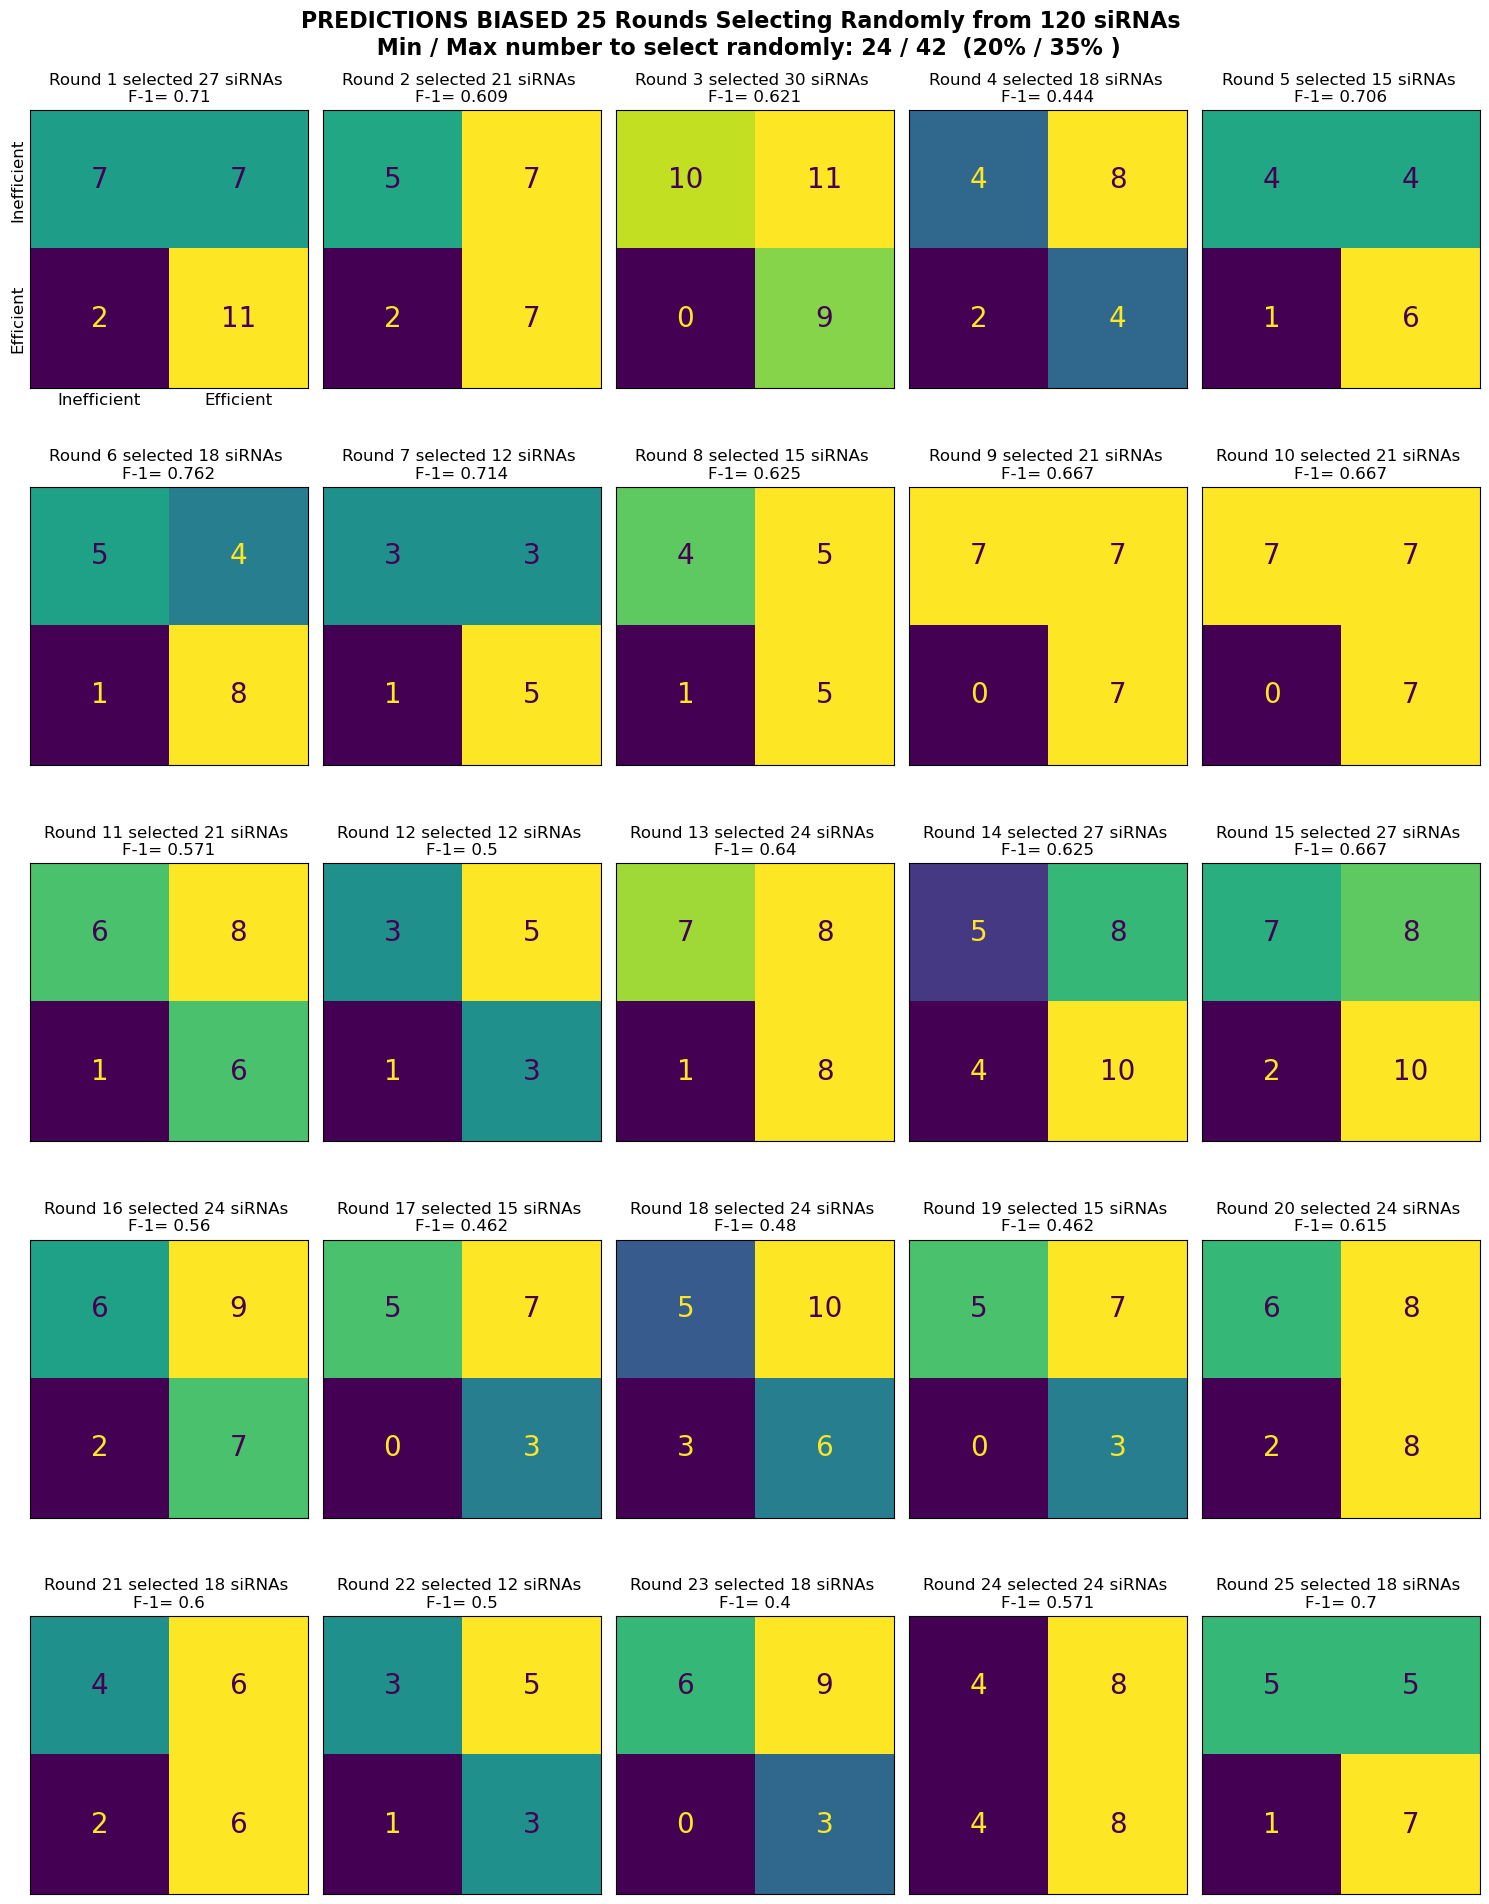

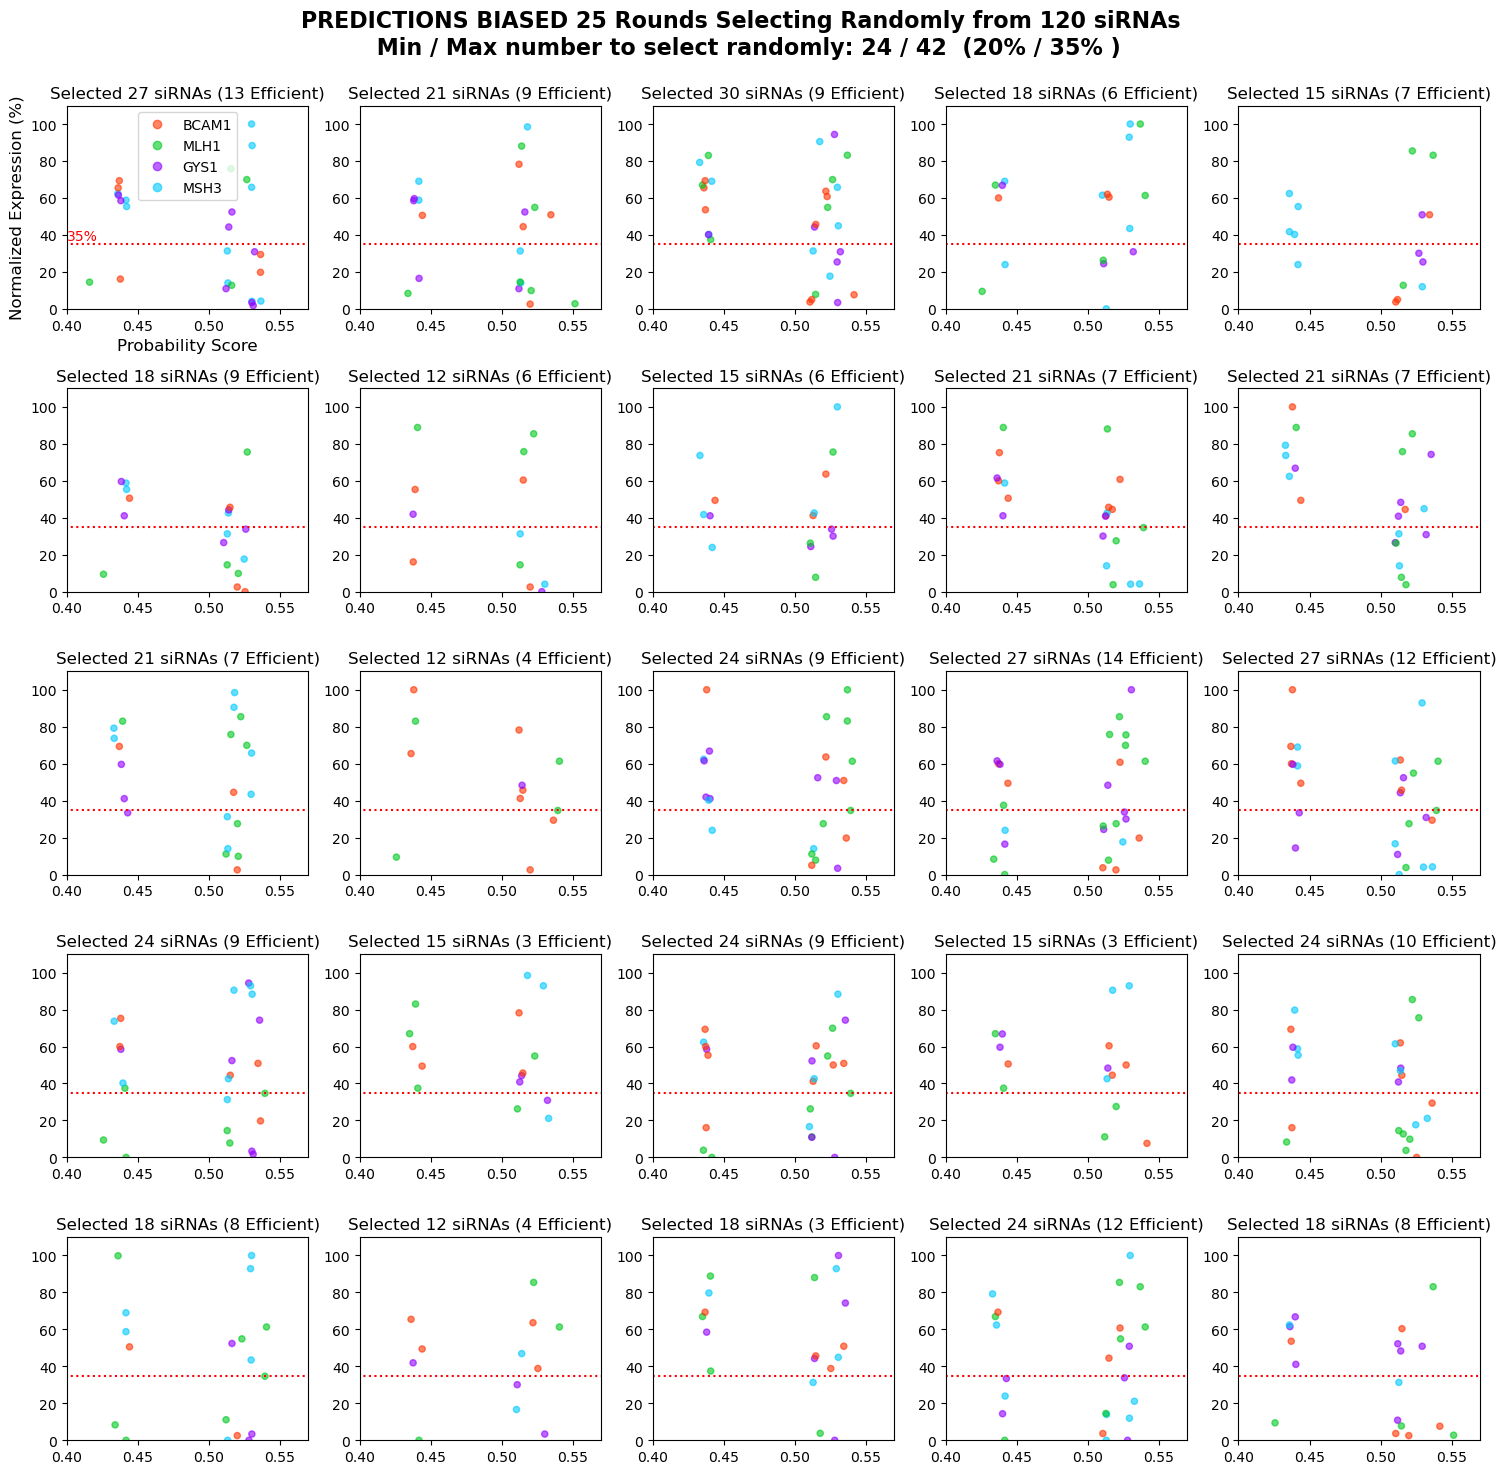

In [430]:
min_size = int(len(df)*.2)
max_size = int(len(df)*.35)
num_rounds_ = 25


min_size_pcnt = int(np.round(100*(min_size/len(df)),0))
max_size_pcnt = int(np.round(100*(max_size/len(df)),0))
df.reset_index(inplace=True,drop=True)
import random
import math
# limit range to just numbers divisable by 3 so can pick 1/3 pred nf and 2/3 pred f each round
range_rand_size = [x for x in range_rand_size if x%3 == 0] #list(range(min_size,max_size+1))  
indxs_df_pred_eff = list(df[df['predicted_functional']].index)
indxs_df_pred_ineff = list(df[~df['predicted_functional']].index)



gene_color_dict = {
    'BCAM1' : '#FF3400',
    'MLH1'  : '#00C920',
    'MSH3'  : '#00c9ff',
    'GYS1'  : '#9200ff'
}

ncols_ = 5
fig_cm,axs_cm = plt.subplots(math.ceil(num_rounds_/ncols_),ncols_)
fig_cm.set_size_inches(w=15,h=20)
fig_ex,axs_ex = plt.subplots(math.ceil(num_rounds_/ncols_),ncols_)
fig_ex.set_size_inches(w=15,h=15)

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

print('Sample size per round\nmin size:',min_size,'\tmax size:',max_size,'\ttotal:',len(df))
rand_selections_ls = []
cm_rand_selection_ls = []
f1_ls = []
fbeta_ls = []
for round_ct_ in range(num_rounds_):
    size_round_ = random.sample(range_rand_size, 1)[0]
    #print('Round '+str(round_ct_+1)+' size:',size_round_)

    # select size_round_ siRNAs randomly but with 1/3 predicted inefficeint and 2/3 predicted efficient
    size_round_pred_eff_ = int(2*(size_round_/3))
    size_round_pred_ineff_ = int(size_round_/3)

    # print(size_round_,size_round_pred_eff_,size_round_pred_ineff_)
    rand_sirnas_eff = random.sample(indxs_df_pred_eff, size_round_pred_eff_)
    rand_sirnas_ineff = random.sample(indxs_df_pred_ineff, size_round_pred_ineff_)
    rand_sirnas = rand_sirnas_eff+rand_sirnas_ineff
    # display(df.iloc[rand_sirnas])



    rand_selections_ls.append(rand_sirnas)
    
    # Compute F1 scores for selection
    y_true = df.iloc[rand_sirnas]['actually_functional']
    y_pred = df.iloc[rand_sirnas]['raw_probabilities_mean'].apply(lambda x: x >= 0.5) 
    
    f1_macro_ = np.round(f1_score(y_true, y_pred, average='macro'),3)
    f1_micro_ = np.round(f1_score(y_true, y_pred, average='micro'),3)
    f1_weighted_ = np.round(f1_score(y_true, y_pred, average='weighted'),3)
    f1_binary_ = np.round(f1_score(y_true, y_pred, average='binary'),3)
    
    beta_ = 0.25
    
    fbeta_macro_ = np.round(fbeta_score(y_true, y_pred, average='macro', beta=beta_),3)
    fbeta_micro_ = np.round(fbeta_score(y_true, y_pred, average='micro', beta=beta_),3)
    fbeta_weighted_ = np.round(fbeta_score(y_true, y_pred, average='weighted', beta=beta_),3)
    fbeta_binary_ = np.round(fbeta_score(y_true, y_pred, average='binary', beta=beta_),3)
    
    fbeta_ls.append(fbeta_binary_)
    f1_ls.append(f1_binary_)
    
    
    
    
    # Plot Confusion Matrix
    ax_cm = axs_cm[int(round_ct_/ncols_),round_ct_%ncols_]

    cm = confusion_matrix(
        df.iloc[rand_sirnas]['normalized_expression_percent'].apply(lambda x: x <= 35),
        df.iloc[rand_sirnas]['raw_probabilities_mean'].apply(lambda x: x >= 0.5))

    cm_rand_selection_ls.append(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Nonfunctional","Functional"])
    disp.plot(ax=ax_cm,colorbar=False)
    
    for txt in ax_cm.texts:
        txt.set_fontsize(20)
        
    ax_cm.set_ylabel('')
    ax_cm.set_xlabel('')
    ax_cm.tick_params(axis=u'both', which=u'both',length=0)

    if round_ct_ == 0:
        ax_cm.set_yticklabels(['Inefficient','Efficient'],rotation=90,fontsize=12,fontdict={'horizontalalignment':'right','verticalalignment':'center'})
        ax_cm.set_xticklabels(['Inefficient','Efficient'],rotation=0,fontsize=12)
    else:
        ax_cm.set_yticklabels([])
        ax_cm.set_xticklabels([])
    ax_cm.set_title('Round '+str(round_ct_+1)+' selected '+str(size_round_)+' siRNAs \nF-1= '+str(f1_binary_))#+' ('+str(fbeta_binary_)+')')



    
    num_ineff_ = df.iloc[rand_sirnas]['normalized_expression_percent'].apply(lambda x: x<=35).value_counts()[False]
    num_eff_ = len(rand_sirnas)-num_ineff_


    # Plot Expression vs. Probabilities
    ax_ex = axs_ex[int(round_ct_/ncols_),round_ct_%ncols_]
    cols_by_gene = df.iloc[rand_sirnas]['gene'].apply(lambda x: gene_color_dict[x])

    df.iloc[rand_sirnas].plot.scatter(
        x='raw_probabilities_mean',
        # y='avg_raw_expression_percent',
        y='normalized_expression_percent',
        marker='o',
        alpha=0.6,
        c = cols_by_gene,
        ax=ax_ex,
        # title='msh3'.upper()+' top from each position group',
    )

    expr_co_ = 35
    ax_ex.hlines(y=expr_co_, xmin=0, xmax=(max(df[(df['gene'] == gene_)]['position'])), linestyle='dotted',color='red')
    

    # ax_ex.set_title('Round '+str(round_ct_+1)+' selected '+str(size_round_)+' siRNAs \n Efficient = '+str(num_eff_)+' | Inefficient = '+str(num_ineff_))
    ax_ex.set_title('Selected '+str(size_round_)+' siRNAs ('+str(num_eff_)+' Efficient)')

    ax_ex.set_ylim(0,110)
    ax_ex.set_xlim(0.4,0.57)

    if round_ct_ == 0:
        ax_ex.annotate(str(expr_co_)+'%',(0.40,expr_co_+2),color='red')
        legend_elements = [Line2D([0],[0],marker='o',color=gene_color_dict[g],linestyle='None',markersize=6,label=g,alpha=0.6) for g in ['BCAM1', 'MLH1', 'GYS1', 'MSH3']]
        ax_ex.legend(handles=legend_elements,loc='best',frameon=True,fontsize=10)#,bbox_to_anchor=(1.3, 1.0))
        ax_ex.set_ylabel('Normalized Expression (%)',fontsize=12)
        ax_ex.set_xlabel('Probability Score',fontsize=12)
    else:
        ax_ex.set_ylabel('')
        ax_ex.set_xlabel('')

# remove remaining axes from confusion matrix figure
for ct_ in range(len(axs_cm[0])*len(axs_cm)):
    if axs_cm[int(ct_/ncols_),ct_%ncols_].get_title() == '':
        axs_cm[int(ct_/ncols_),ct_%ncols_].remove()

fig_cm.suptitle(('PREDICTIONS BIASED '+str(num_rounds_)+' Rounds Selecting Randomly from '+str(len(df))+' siRNAs \n Min / Max number to select randomly: '+str(min_size)+' / '+str(max_size) +'  ('+str(min_size_pcnt)+'% / '+str(max_size_pcnt)+'% )'),
            fontsize=16,fontweight='bold')
fig_cm.tight_layout()



# remove remaining axes from confusion matrix figure
for ct_ in range(len(axs_ex[0])*len(axs_ex)):
    if axs_ex[int(ct_/ncols_),ct_%ncols_].get_title() == '':
        axs_ex[int(ct_/ncols_),ct_%ncols_].remove()

fig_ex.suptitle(('PREDICTIONS BIASED '+str(num_rounds_)+' Rounds Selecting Randomly from '+str(len(df))+' siRNAs \n Min / Max number to select randomly: '+str(min_size)+' / '+str(max_size) +'  ('+str(min_size_pcnt)+'% / '+str(max_size_pcnt)+'% )\n'),
            fontsize=16,fontweight='bold')
fig_ex.tight_layout()



## Save Figures
fnm_final_cm = 'PRED-BIASED-'+str(num_rounds_)+'_rounds_'+str(min_size)+'-to-'+str(max_size)+'_random_sampling_confusion_matrix_filtered_no_pos_bias'

fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
fig_cm.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
fig_cm.savefig(fnm_final_dir_+fnm_final_cm+'.svg',format='svg',transparent=True)
fig_cm.savefig(fnm_final_dir_+fnm_final_cm+'.png',format='png',dpi=300,transparent=False)
print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final_cm + '.png\n\t'+ fnm_final_cm + '.svg')
    
## Save Figures
fnm_final_ex = 'PRED-BIASED-'+str(num_rounds_)+'_rounds_'+str(min_size)+'-to-'+str(max_size)+'_random_sampling_expression-vs-prob-score_filtered_no_pos_bias'

fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
fig_ex.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
fig_ex.savefig(fnm_final_dir_+fnm_final_ex+'.svg',format='svg',transparent=True)
fig_ex.savefig(fnm_final_dir_+fnm_final_ex+'.png',format='png',dpi=300,transparent=False)
print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final_ex + '.png\n\t'+ fnm_final_ex + '.svg')
    


# Plot all selections together (with error bars)

[[5.32 6.96]
 [1.36 6.4 ]]
Figures saved to:
  /Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/
	PRED-BIASED_CUMULATIVE-MATRIX_25_rounds_24-to-42_random_sampling_filtered_no_pos_bias.png
	PRED-BIASED_CUMULATIVE-MATRIX_25_rounds_24-to-42_random_sampling_filtered_no_pos_bias.svg


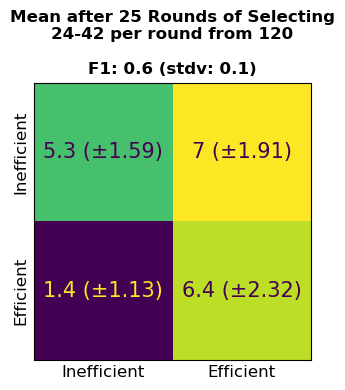

In [431]:
ii_ls=[]
ie_ls=[]
ei_ls=[]
ee_ls=[]

for round_ in range(len(rand_selections_ls)):
    # print(rand_selections_ls[round_])
    ii_ls.append(cm_rand_selection_ls[round_][0][0])
    ie_ls.append(cm_rand_selection_ls[round_][0][1])
    ei_ls.append(cm_rand_selection_ls[round_][1][0])
    ee_ls.append(cm_rand_selection_ls[round_][1][1])



cm_mean = np.array(
    [np.array([np.mean(ii_ls),np.mean(ie_ls)]),
     np.array([np.mean(ei_ls),np.mean(ee_ls)])]
)

cm_std = [np.round(np.std(ii_ls),2),np.round(np.std(ie_ls),2),
          np.round(np.std(ei_ls),2),np.round(np.std(ee_ls),2)]
print(cm_mean)


# Plot Confusion Matrix
fig,ax = plt.subplots()
fig.set_size_inches(w=4,h=4)
# cm = confusion_matrix(
#     df.iloc[rand_sirnas]['normalized_expression_percent'].apply(lambda x: x <= 35),
#     df.iloc[rand_sirnas]['raw_probabilities_mean'].apply(lambda x: x >= 0.5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mean,display_labels=["Nonfunctional","Functional"])
disp.plot(ax=ax,colorbar=False)

for txt,std_ in zip(ax.texts,cm_std):
    txt.set_fontsize(15)
    lab_ = txt.get_text()+' (±'+str(std_)+')'
    txt.set_text(lab_)
    
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis=u'both', which=u'both',length=0)

ax.set_yticklabels(['Inefficient','Efficient'],rotation=90,fontsize=12,fontdict={'horizontalalignment':'right','verticalalignment':'center'})
ax.set_xticklabels(['Inefficient','Efficient'],rotation=0,fontsize=12)

ax.set_title(
    'Mean after '+str(num_rounds_)+' Rounds of Selecting\n'+str(min_size)+'-'+str(max_size)+' per round from '+str(len(df))+(
        '\n\nF1: '+str(np.round(np.mean(f1_ls),2))+' (stdv: '+str(np.round(np.std(f1_ls),2))+')'
    ),
    fontweight='bold')


    
## Save Figures
fnm_final = 'PRED-BIASED_CUMULATIVE-MATRIX_'+str(num_rounds_)+'_rounds_'+str(min_size)+'-to-'+str(max_size)+'_random_sampling_filtered_no_pos_bias'

fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
fig.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
fig.savefig(fnm_final_dir_+fnm_final+'.svg',format='svg',transparent=True)
fig.savefig(fnm_final_dir_+fnm_final+'.png',format='png',dpi=300,transparent=False)
print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final + '.png\n\t'+ fnm_final + '.svg')
    



Sample size per round
min size: 12 	max size: 24 	total: 120
[[4.28 5.16]
 [1.36 6.12]]


Text(0.5, 1.0, 'Mean after 25 Rounds of Selecting\n12-24 per round from 120\n\nF1: 0.65 (stdv: 0.14)')

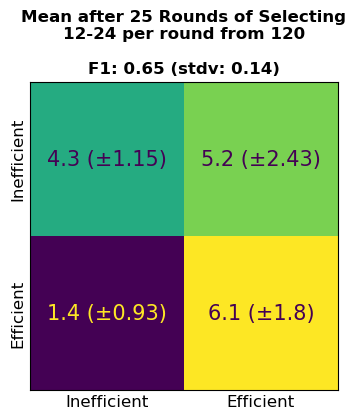

In [441]:
min_size = int(len(df)*.1)
max_size = int(len(df)*.2)
num_rounds_ = 25


min_size_pcnt = int(np.round(100*(min_size/len(df)),0))
max_size_pcnt = int(np.round(100*(max_size/len(df)),0))
df.reset_index(inplace=True,drop=True)
import random
import math
# range_rand_size = list(range(min_size,max_size+1))  
range_rand_size = [x for x in range_rand_size if x%3==0]

gene_color_dict = {
    'BCAM1' : '#FF3400',
    'MLH1'  : '#00C920',
    'MSH3'  : '#00c9ff',
    'GYS1'  : '#9200ff'
}


from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

print('Sample size per round\nmin size:',min_size,'\tmax size:',max_size,'\ttotal:',len(df))

rand_selections_ls = []
cm_rand_selection_ls = []
f1_ls = []
fbeta_ls = []
for round_ct_ in range(num_rounds_):
    size_round_ = random.sample(range_rand_size, 1)[0]
    size_round_pred_eff_ = int(2*(size_round_/3))
    size_round_pred_ineff_ = int(size_round_/3)

    rand_sirnas_eff = random.sample(indxs_df_pred_eff, size_round_pred_eff_)
    rand_sirnas_ineff = random.sample(indxs_df_pred_ineff, size_round_pred_ineff_)
    rand_sirnas = rand_sirnas_eff+rand_sirnas_ineff

    # rand_sirnas = random.sample(list(df.index), size_round_)
    
    rand_selections_ls.append(rand_sirnas)



    
    
    # Compute F1 scores for selection
    y_true = df.iloc[rand_sirnas]['actually_functional']
    y_pred = df.iloc[rand_sirnas]['raw_probabilities_mean'].apply(lambda x: x >= 0.5) 
    
    f1_macro_ = np.round(f1_score(y_true, y_pred, average='macro'),3)
    f1_micro_ = np.round(f1_score(y_true, y_pred, average='micro'),3)
    f1_weighted_ = np.round(f1_score(y_true, y_pred, average='weighted'),3)
    f1_binary_ = np.round(f1_score(y_true, y_pred, average='binary'),3)
    
    beta_ = 0.25
    
    fbeta_macro_ = np.round(fbeta_score(y_true, y_pred, average='macro', beta=beta_),3)
    fbeta_micro_ = np.round(fbeta_score(y_true, y_pred, average='micro', beta=beta_),3)
    fbeta_weighted_ = np.round(fbeta_score(y_true, y_pred, average='weighted', beta=beta_),3)
    fbeta_binary_ = np.round(fbeta_score(y_true, y_pred, average='binary', beta=beta_),3)
    
    fbeta_ls.append(fbeta_binary_)
    f1_ls.append(f1_binary_)
    
    
    # Plot Confusion Matrix
    ax_cm = axs_cm[int(round_ct_/ncols_),round_ct_%ncols_]

    cm = confusion_matrix(
        df.iloc[rand_sirnas]['normalized_expression_percent'].apply(lambda x: x <= 35),
        df.iloc[rand_sirnas]['raw_probabilities_mean'].apply(lambda x: x >= 0.5))

    cm_rand_selection_ls.append(cm)
    
    num_ineff_ = df.iloc[rand_sirnas]['normalized_expression_percent'].apply(lambda x: x<=35).value_counts()[False]
    num_eff_ = len(rand_sirnas)-num_ineff_

ii_ls=[]
ie_ls=[]
ei_ls=[]
ee_ls=[]

for round_ in range(len(rand_selections_ls)):
    # print(rand_selections_ls[round_])
    ii_ls.append(cm_rand_selection_ls[round_][0][0])
    ie_ls.append(cm_rand_selection_ls[round_][0][1])
    ei_ls.append(cm_rand_selection_ls[round_][1][0])
    ee_ls.append(cm_rand_selection_ls[round_][1][1])



cm_mean = np.array(
    [np.array([np.mean(ii_ls),np.mean(ie_ls)]),
     np.array([np.mean(ei_ls),np.mean(ee_ls)])]
)

cm_std = [np.round(np.std(ii_ls),2),np.round(np.std(ie_ls),2),
          np.round(np.std(ei_ls),2),np.round(np.std(ee_ls),2)]
print(cm_mean)


# Plot Confusion Matrix
fig,ax = plt.subplots()
fig.set_size_inches(w=4,h=4)
# cm = confusion_matrix(
#     df.iloc[rand_sirnas]['normalized_expression_percent'].apply(lambda x: x <= 35),
#     df.iloc[rand_sirnas]['raw_probabilities_mean'].apply(lambda x: x >= 0.5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_mean,display_labels=["Nonfunctional","Functional"])
disp.plot(ax=ax,colorbar=False)

for txt,std_ in zip(ax.texts,cm_std):
    txt.set_fontsize(15)
    lab_ = txt.get_text()+' (±'+str(std_)+')'
    txt.set_text(lab_)
    
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(axis=u'both', which=u'both',length=0)

ax.set_yticklabels(['Inefficient','Efficient'],rotation=90,fontsize=12,fontdict={'horizontalalignment':'right','verticalalignment':'center'})
ax.set_xticklabels(['Inefficient','Efficient'],rotation=0,fontsize=12)

ax.set_title(
    'Mean after '+str(num_rounds_)+' Rounds of Selecting\n'+str(min_size)+'-'+str(max_size)+' per round from '+str(len(df))+(
        '\n\nF1: '+str(np.round(np.mean(f1_ls),2))+' (stdv: '+str(np.round(np.std(f1_ls),2))+')'
    ),
    fontweight='bold')


    
# ## Save Figures
# fnm_final = 'CUMULATIVE-MATRIX_'+str(num_rounds_)+'_rounds_'+str(min_size)+'-to-'+str(max_size)+'_random_sampling_filtered_no_pos_bias'
# fnm_final = 'PRED-BIASED_CUMULATIVE-MATRIX_'+str(num_rounds_)+'_rounds_'+str(min_size)+'-to-'+str(max_size)+'_random_sampling_filtered_no_pos_bias'

# fnm_final_dir_ = '/Users/kmonopoli/Dropbox (UMass Medical School)/sirna_design_algorithm_paper/figures/python_code_to_make_figures/plots/'
# fig.tight_layout()
# plt.rcParams['svg.fonttype'] = 'none'  # exports text as strings rather than vector paths (images)
# fig.savefig(fnm_final_dir_+fnm_final+'.svg',format='svg',transparent=True)
# fig.savefig(fnm_final_dir_+fnm_final+'.png',format='png',dpi=300,transparent=False)
# print('Figures saved to:\n  '+fnm_final_dir_+'\n\t'+ fnm_final + '.png\n\t'+ fnm_final + '.svg')
    




##### bottom
### [top](#top)